# Análisis exploratorio 

* Luisa Merlo García | A01067715
* Edgar Osvaldo Navarro | A01644488
* Ariana Guadalupe Rosales Villalobos | A01644773

## Cargamos el Dataset y revisamos sus dimensiones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import os
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats


# Ajusta la carpeta si el Excel no está junto al notebook
archivo = Path("Datos/Resumen Downtime Current.xlsx")

df_original = pd.read_excel(archivo, sheet_name="2024")

# Trabajamos con una copia para conservar los datos originales
df = df_original.copy()
df.columns = df.columns.str.strip()

print("Forma del dataset:", df.shape)
print("Cantidad de registros:", df.shape[0])
print("Cantidad de variables:", df.shape[1])

display(df.head())
df.info()

print("\nFecha mínima de apertura:", df["Opened"].min())
print("Fecha máxima de apertura:", df["Opened"].max())

Forma del dataset: (10167, 28)
Cantidad de registros: 10167
Cantidad de variables: 28


,Equipo,Opened,Update,Reason,Ticket,Downtime,ISSUE 13,Description 9,Work Description (Close Details) 17,Dia,...,Año,Fecha completa,2nd class 29,ss,Corrective,Class2 29,Eq Type 26,Automotive? As on Aug-2024,Brand,Model
0,Preferida,2026-08-23 23:50:52.500,2026-08-24 00:14:31.837,MANTENIMIENTO - MANTTO. CORRECTIVO,REQ-1760551,0.39426,Mechanical Failure,Favor de checar giro intermedio de fin de braz...,Se extrae tonillo capado de sujecion de block ...,2026-08-23 23:50:52.500,...,2026,2026 - 8,Robot Wrist problem,1,Corrective,Robot Wrist problem,Robot,NO,SEPRO,S5-35 S3 AXIAL
1,LaBarranca,2026-08-23 23:25:43.213,2026-08-23 23:27:48.213,MANTENIMIENTO - MANTTO. CORRECTIVO,REQ-1760257,0.034722,Calibration Parameter Modification,Favor de revisar falla de presion de cierre,Restablece maquina 2 veces en turno\nSe ajusta...,2026-08-23 23:25:43.213,...,2026,2026 - 8,Clamping/ejector movement problems,1,Corrective,Clamping/ejector movement problems,IMM,NO,KRAUSS MAFFEI,KM420-1900C2
2,Ruisenores,2026-08-23 23:21:46.997,2026-08-24 00:05:28.297,MANTENIMIENTO - MANTTO. CORRECTIVO,REQ-1760550,0.728139,Clamping Piston Failure,Favor de checar nivel de aceite bajo se apaga ...,Realiza recuperacion de nivel de aceite en maq...,2026-08-23 23:21:46.997,...,2026,2026 - 8,Oil Alarm,1,Corrective,Oil Alarm,IMM,NO,NISSEI,FV9000
3,LaBarranca,2026-08-23 21:23:06.703,2026-08-23 21:28:53.060,MANTENIMIENTO - MANTTO. CORRECTIVO,REQ-1760257,0.09621,Calibration Parameter Modification,Favor de revisar falla de presion de cierre,Restablece maquina 2 veces en turno\nSe ajusta...,2026-08-23 21:23:06.703,...,2026,2026 - 8,Clamping/ejector movement problems,1,Corrective,Clamping/ejector movement problems,IMM,NO,KRAUSS MAFFEI,KM420-1900C2
4,Canada,2026-08-23 20:54:49.517,2026-08-23 21:05:09.210,MANTENIMIENTO - MANTTO. CORRECTIVO,REQ-1760499,0.172137,Process Adjustment,Favor de colocar barra donde se embobinado ro...,se volvio a fijar barra de el winder,2026-08-23 20:54:49.517,...,2026,2026 - 8,Foil feeder,1,Corrective,Foil feeder,Feeder,NO,WITTMANN,Feeder


<class 'pandas.DataFrame'>
RangeIndex: 10167 entries, 0 to 10166
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Equipo                               10167 non-null  str           
 1   Opened                               10167 non-null  datetime64[us]
 2   Update                               10167 non-null  datetime64[us]
 3   Reason                               10167 non-null  str           
 4   Ticket                               10162 non-null  str           
 5   Downtime                             10167 non-null  object        
 6   ISSUE 13                             8383 non-null   object        
 7   Description 9                        8386 non-null   object        
 8   Work Description (Close Details) 17  8384 non-null   object        
 9   Dia                                  10167 non-null  datetime64[us]
 10  mes                  

El dataset contiene 10,167 registros y 28 variables. Cada fila representa un registro de downtime asociado a un equipo y, cuando está disponible, a un ticket. Un mismo ticket puede aparecer en varios registros, por lo que el número de filas no equivale al número de tickets únicos. Aunque la hoja se llama “2024”, las fechas de apertura abarcan del 2 de enero de 2025 al 23 de agosto de 2026.

## Identificamos los tipos de variables


In [2]:
tipos_variables = {
    "Equipo": "Categórica nominal",
    "Opened": "Temporal: fecha y hora",
    "Update": "Temporal: fecha y hora",
    "Reason": "Categórica nominal",
    "Ticket": "Identificador",
    "Downtime": "Cuantitativa continua",
    "ISSUE 13": "Categórica nominal",
    "Description 9": "Texto libre",
    "Work Description (Close Details) 17": "Texto libre",
    "Dia": "Temporal: fecha y hora",
    "mes": "Temporal: mes",
    "Semana": "Temporal: año y semana",
    "Equipo 26": "Categórica nominal",
    "Sub system 27": "Categórica nominal",
    "EQ2": "Identificador compuesto de equipo",
    "Clase 13": "Categórica nominal",
    "DD": "Identificador compuesto",
    "Device 28": "Categórica nominal",
    "Año": "Temporal: año",
    "Fecha completa": "Temporal: año y mes",
    "2nd class 29": "Categórica nominal",
    "ss": "Código numérico por documentar",
    "Corrective": "Categórica nominal",
    "Class2 29": "Categórica nominal",
    "Eq Type 26": "Categórica nominal",
    "Automotive? As on Aug-2024": "Categórica nominal",
    "Brand": "Categórica nominal",
    "Model": "Categórica nominal"
}

resumen_variables = pd.DataFrame({
    "Tipo en pandas": df.dtypes.astype(str),
    "Tipo de variable": pd.Series(tipos_variables),
    "Valores únicos": df.nunique()
})

display(resumen_variables)

,Tipo en pandas,Tipo de variable,Valores únicos
Equipo,str,Categórica nominal,92
Opened,datetime64[us],Temporal: fecha y hora,10159
Update,datetime64[us],Temporal: fecha y hora,10145
Reason,str,Categórica nominal,4
Ticket,str,Identificador,5000
Downtime,object,Cuantitativa continua,10143
ISSUE 13,object,Categórica nominal,95
Description 9,object,Texto libre,4594
Work Description (Close Details) 17,object,Texto libre,3873
Dia,datetime64[us],Temporal: fecha y hora,10159


Observamos que predominan las variables categricas,los identificadores y campos temporales. Downtime corresponde a una metrica de duración pero pandas lo carga como object.

## Revisar valores faltantes

In [3]:
# Contamos valores faltantes de cada columna
faltantes = pd.DataFrame({
    "Cantidad": df.isna().sum(),
    "Porcentaje": (df.isna().mean() * 100).round(2)
})

faltantes = faltantes.sort_values("Cantidad", ascending=False)

display(faltantes)

print("Total de celdas faltantes:", df.isna().sum().sum())
print("Filas con al menos un faltante:", df.isna().any(axis=1).sum())

# También buscamos texto vacio o  espacios
columnas_texto = df.select_dtypes(include=["object", "string"]).columns

vacios = {}

for columna in columnas_texto:
    valores = df[columna].astype("string")
    vacios[columna] = valores.str.strip().eq("").sum()

display(
    pd.Series(vacios, name="Textos vacíos")
    .sort_values(ascending=False)
)

,Cantidad,Porcentaje
ISSUE 13,1784,17.55
Clase 13,1784,17.55
Sub system 27,1783,17.54
Work Description (Close Details) 17,1783,17.54
Eq Type 26,1783,17.54
Description 9,1781,17.52
Model,1605,15.79
Brand,1491,14.67
Class2 29,1354,13.32
2nd class 29,1349,13.27


Total de celdas faltantes: 20889
Filas con al menos un faltante: 2479


Equipo                                 0
Reason                                 0
Ticket                                 0
Downtime                               0
ISSUE 13                               0
Description 9                          0
Work Description (Close Details) 17    0
Semana                                 0
Equipo 26                              0
Sub system 27                          0
EQ2                                    0
Clase 13                               0
DD                                     0
Device 28                              0
Fecha completa                         0
2nd class 29                           0
Corrective                             0
Class2 29                              0
Eq Type 26                             0
Automotive? As on Aug-2024             0
Brand                                  0
Model                                  0
Name: Textos vacíos, dtype: int64

Entre las variables con más faltantes están ISSUE 13 y Clase 13, con 1,784 cada una, y los campos de descripción y clasificación del equipo. Ticket tiene cinco valores faltantes. No se eliminaran estas filas ya que existen campos con informacion util en otros casos.

In [4]:
# Revisamos posibles informacion faltante, marcada como 0
reporte_marcadores = []

for columna in columnas_texto:
    valores = df[columna].astype("string").str.strip().str.casefold()

    reporte_marcadores.append({
        "Variable": columna,
        "Ceros escritos o numéricos": valores.isin(["0", "0.0"]).sum(),
        "Contiene 'sin ticket'": valores.str.contains(
            "sin ticket", regex=False, na=False
        ).sum()
    })

reporte_marcadores = pd.DataFrame(reporte_marcadores)

display(
    reporte_marcadores[
        (reporte_marcadores["Ceros escritos o numéricos"] > 0) |
        (reporte_marcadores["Contiene 'sin ticket'"] > 0)
    ]
)

,Variable,Ceros escritos o numéricos,Contiene 'sin ticket'
2,Ticket,0,1765
3,Downtime,0,1
4,ISSUE 13,1602,0
6,Work Description (Close Details) 17,1507,0
8,Equipo 26,154,0
9,Sub system 27,3281,0
11,Clase 13,1602,0
18,Eq Type 26,154,0


Se observan ceros en campos descriptivos y de clasificación. Estos podrían representar información no registrada o informacion que no es necesari a en ese caso. Además, 1,765 registros contienen “Sin Ticket”, incluyendo variantes y descripciones adicionales.

## Revisar duplicados 

In [5]:
# Duplicados considerando todas las columnas
duplicados_completos = df.duplicated()

print("Filas completamente duplicadas:", duplicados_completos.sum())

# Posibles registros repetidos del mismo evento
clave_evento = ["Ticket", "Equipo", "Opened", "Update"]

print(
    "Repeticiones de la clave del evento:",
    df.duplicated(subset=clave_evento).sum()
)

# Revisamos la repetición de identificadores con formato REQ-número
tickets = df["Ticket"].astype("string").str.strip()
es_req = tickets.str.fullmatch(r"REQ-\d+", na=False)

frecuencia_tickets = tickets[es_req].value_counts()

print("\nRegistros con formato REQ-número:", es_req.sum())
print("Tickets REQ distintos:", tickets[es_req].nunique())
print(
    "Apariciones adicionales de tickets REQ:",
    tickets[es_req].duplicated().sum()
)

display(
    frecuencia_tickets[frecuencia_tickets > 1]
    .head(10)
    .rename("Cantidad de registros")
)

# Mostramos un ejemplo del ticket más frecuente
if not frecuencia_tickets.empty:
    ticket_ejemplo = frecuencia_tickets.index[0]

    display(
        df.loc[
            tickets.eq(ticket_ejemplo).fillna(False),
            ["Ticket", "Equipo", "Opened", "Update", "Downtime"]
        ].sort_values("Opened").head(10)
    )

Filas completamente duplicadas: 0
Repeticiones de la clave del evento: 0

Registros con formato REQ-número: 8388
Tickets REQ distintos: 4931
Apariciones adicionales de tickets REQ: 3457


Ticket
REQ-1684425    102
REQ-1518418     54
REQ-1682059     32
REQ-1678991     28
REQ-1721473     25
REQ-1602471     22
REQ-1742067     20
REQ-1760257     19
REQ-1730625     17
REQ-1603477     17
Name: Cantidad de registros, dtype: Int64

,Ticket,Equipo,Opened,Update,Downtime
2389,REQ-1684425,LaBarranca,2026-04-08 01:43:44.420,2026-04-08 01:47:27.543,0.061979
2388,REQ-1684425,LaBarranca,2026-04-08 02:13:47.460,2026-04-08 02:15:41.050,0.031553
2387,REQ-1684425,LaBarranca,2026-04-08 03:08:44.540,2026-04-08 03:10:06.147,0.022669
2386,REQ-1684425,LaBarranca,2026-04-08 04:13:32.713,2026-04-08 04:15:28.520,0.032169
2384,REQ-1684425,LaBarranca,2026-04-08 06:31:59.750,2026-04-08 06:33:47.760,0.030003
2380,REQ-1684425,LaBarranca,2026-04-08 11:21:34.440,2026-04-08 11:22:13.137,0.010749
2378,REQ-1684425,LaBarranca,2026-04-08 12:27:27.073,2026-04-08 12:28:25.107,0.016121
2376,REQ-1684425,LaBarranca,2026-04-08 13:47:04.073,2026-04-08 13:51:14.053,0.069439
2374,REQ-1684425,LaBarranca,2026-04-08 16:21:49.817,2026-04-08 16:25:20.510,0.058526
2372,REQ-1684425,LaBarranca,2026-04-08 16:55:07.113,2026-04-08 16:59:44.310,0.076999


No se encontraron filas completamente duplicadas ni repeticiones de la combinación Ticket, Equipo, Opened y Update. dentificaron 8,388 registros con formato REQ-número, correspondientes a 4,931 tickets distintos. Las 3,457 apariciones adicionales no deben eliminarse,aún ya que pueden representar diferentes eventos asociados al mismo ticket.

## Revisamos valores inconsistentes 

In [6]:
# Convertimos en variables auxiliares para detectar errores
downtime = pd.to_numeric(df["Downtime"], errors="coerce")
opened = pd.to_datetime(df["Opened"], errors="coerce")
update = pd.to_datetime(df["Update"], errors="coerce")

# Valores presentes que no pudieron convertirse
downtime_no_numerico = df["Downtime"].notna() & downtime.isna()
opened_invalido = df["Opened"].notna() & opened.isna()
update_invalido = df["Update"].notna() & update.isna()

# Calculamos el intervalo en horas
duracion_calculada = (update - opened).dt.total_seconds() / 3600

# Comparamos únicamente los casos numéricos finitos y con ambas fechas
comparables = (
    downtime.notna() &
    np.isfinite(downtime) &
    opened.notna() &
    update.notna()
)

# Tolerancia de un segundo por posibles diferencias de precisión
diferencia_duracion = (
    comparables &
    ((downtime - duracion_calculada).abs() > 1 / 3600)
)

revision = pd.Series({
    "Downtime no numérico": downtime_no_numerico.sum(),
    "Downtime negativo": downtime.lt(0).sum(),
    "Downtime igual a cero": downtime.eq(0).sum(),
    "Downtime infinito": np.isinf(downtime).sum(),
    "Opened no convertible": opened_invalido.sum(),
    "Update no convertible": update_invalido.sum(),
    "Update anterior a Opened": (update < opened).sum(),
    "Downtime diferente del intervalo calculado": diferencia_duracion.sum(),
    "Mes fuera de 1 a 12": (~df["mes"].between(1, 12)).sum(),
    "Mes distinto al de Opened": (df["mes"] != opened.dt.month).sum(),
    "Año distinto al de Opened": (df["Año"] != opened.dt.year).sum()
}, name="Cantidad")

display(revision)

# Mostramos los registros que requieren revisión
casos_revision = df.loc[
    downtime_no_numerico | diferencia_duracion,
    ["Ticket", "Equipo", "Opened", "Update", "Downtime"]
].copy()

casos_revision["Duración calculada (horas)"] = duracion_calculada.loc[
    casos_revision.index
]

display(casos_revision)
display(downtime.describe())

Downtime no numérico                          1
Downtime negativo                             0
Downtime igual a cero                         0
Downtime infinito                             0
Opened no convertible                         0
Update no convertible                         0
Update anterior a Opened                      0
Downtime diferente del intervalo calculado    1
Mes fuera de 1 a 12                           0
Mes distinto al de Opened                     0
Año distinto al de Opened                     0
Name: Cantidad, dtype: int64

,Ticket,Equipo,Opened,Update,Downtime,Duración calculada (horas)
4946,Sin Ticket,Senai,2025-10-25 02:47:00.310,2025-10-25 02:55:29.707,Sin Ticket,0.141499
5999,REQ-1592932,Chamaco,2025-08-21 19:31:27.957,2025-08-21 20:19:51.460,0.016811,0.806529


count    10166.000000
mean         1.009662
std          2.210159
min          0.000084
25%          0.109107
50%          0.393640
75%          1.051657
max         67.824991
Name: Downtime, dtype: float64

Se encontró un registro con “Sin Ticket” dentro de Downtime, donde se esperaba un número. Tampoco se encontraron fechas Update anteriores a Opened, ni inconsistencias de mes o año respecto a la apertura. Se detectó un registro numérico cuya duración difiere del intervalo entre fechas en más de un segundo.

In [7]:

# REvisamos variables categoricas

espacios = {}

for columna in columnas_texto:
    valores = df[columna].astype("string")
    espacios[columna] = valores.ne(valores.str.strip()).sum()

espacios = pd.Series(espacios, name="Registros con espacios externos")

display(espacios[espacios > 0].sort_values(ascending=False))

# Frecuencias de campos que conviene revisar
for columna in ["Corrective", "Equipo 26", "Eq Type 26", "ss"]:
    print(f"\nValores de {columna}:")
    display(df[columna].value_counts(dropna=False))

# Categorías inesperadas según el significado aparente de Corrective
corrective = df["Corrective"].astype("string").str.strip()

categoria_inesperada = (
    corrective.notna() &
    ~corrective.isin(["Corrective", "NOT CORRECTIVE"])
)

display(
    df.loc[
        categoria_inesperada,
        ["Ticket", "Corrective", "2nd class 29"]
    ]
)


Description 9                          4705
Work Description (Close Details) 17     770
ISSUE 13                                338
Clase 13                                338
Model                                    31
Equipo 26                                 8
Eq Type 26                                8
Name: Registros con espacios externos, dtype: int64


Valores de Corrective:


Corrective
Corrective                   7716
NaN                          1258
NOT CORRECTIVE               1192
Failure in axis movements       1
Name: count, dtype: int64


Valores de Equipo 26:


Equipo 26
IMM                   5056
Robot                 2050
NaN                    963
Secador                458
Termoregulador         456
Blender                345
Cargador               224
0                      154
Fixture                142
Controlador            100
Feeder                  61
Security Cage           42
Horno UV                32
Cortadora               16
Hydraulic Unit          10
Foil Feeder              8
Slider                   8
hs                       7
Unidad Hidraulica        6
Foil Feeder              3
Dryer                    3
robot                    3
controlador              2
HS                       2
Hot Pack                 2
Molde                    2
Jalisco                  2
Andom                    2
Spare parts wh           2
Control Hot Runner       1
Hot pack                 1
Coradora                 1
fixture                  1
Power unit               1
hot Pack                 1
Name: count, dtype: int64


Valores de Eq Type 26:


Eq Type 26
IMM                   4279
Robot                 2035
NaN                   1783
Secador                452
Termoregulador         449
Blender                345
Cargador               223
0                      154
Fixture                136
Controlador            100
Feeder                  61
Security Cage           42
Horno UV                32
Cortadora               16
Foil Feeder              8
Slider                   8
hs                       7
Hydraulic Unit           7
Unidad Hidraulica        6
Foil Feeder              3
Dryer                    3
robot                    3
controlador              2
Molde                    2
Jalisco                  2
Andom                    2
Hot Pack                 1
Control Hot Runner       1
Hot pack                 1
Coradora                 1
fixture                  1
Power unit               1
hot Pack                 1
Name: count, dtype: int64


Valores de ss:


ss
1    10161
2        6
Name: count, dtype: int64

,Ticket,Corrective,2nd class 29
3758,Sin Ticket - Robot,Failure in axis movements,Failure in axis movements


Se encontraron espacios externos en siete columnas. La más afectada es Description 9, con 4,705 registros, seguida de Work Description (Close Details) 17, con 770. Por lo que se manejará con un .split() para que no se distingan un mismo valor no se considere como valores distintos.

Tambien econtramos un posible error de captura en Failiure axis movement.

Tambien se observamn inconsistencias en algunos vaalores que existen en las identidades de Equipo 26 y ED Type 26. Con diferencias de mayusculas que generan categorias separadas.

## Revisamos variables redundantes:



In [8]:
pares = [
    ("Opened", "Dia"),
    ("ISSUE 13", "Clase 13"),
    ("2nd class 29", "Class2 29"),
    ("Equipo 26", "Eq Type 26")
]

for columna_1, columna_2 in pares:
    iguales = (
        df[columna_1].eq(df[columna_2]) |
        (df[columna_1].isna() & df[columna_2].isna())
    )

    print(
        f"{columna_1} / {columna_2}: "
        f"{(~iguales).sum()} registros diferentes"
    )

print("\nColumnas constantes:")
display(df.nunique(dropna=False)[df.nunique(dropna=False) == 1])

Opened / Dia: 0 registros diferentes
ISSUE 13 / Clase 13: 0 registros diferentes
2nd class 29 / Class2 29: 8 registros diferentes
Equipo 26 / Eq Type 26: 820 registros diferentes

Columnas constantes:


Automotive? As on Aug-2024    1
dtype: int64

Opened y Dia son idénticas, al igual que ISSUE 13 y Clase 13. Sin embargo, 2nd class 29 y Class2 29 difieren en ocho registros, mientras que Equipo 26 y Eq Type 26 difieren en 820. Por ello, estas últimas no deben tratarse como equivalentes sin revisión. Tambien se encontró Automotive? As on Aug-2024 tiene únicamente el valor NO.

## Aplicamos limpieza de espacios y variables mayusculas

In [9]:
# Eliminamos columnas redundantes o sin variación
columnas_eliminar = [
    "Dia",
    "mes",
    "Año",
    "Fecha completa",
    "Semana",
    "Clase 13",
    "DD",
    "Automotive? As on Aug-2024"
]

# Creamos una tabla nueva para conservar df completo
df_eda = df.drop(columns=columnas_eliminar).copy()

print("Dimensiones originales:", df.shape)
print("Dimensiones después de eliminar columnas:", df_eda.shape)

display(df_eda.head())

Dimensiones originales: (10167, 28)
Dimensiones después de eliminar columnas: (10167, 20)


,Equipo,Opened,Update,Reason,Ticket,Downtime,ISSUE 13,Description 9,Work Description (Close Details) 17,Equipo 26,Sub system 27,EQ2,Device 28,2nd class 29,ss,Corrective,Class2 29,Eq Type 26,Brand,Model
0,Preferida,2026-08-23 23:50:52.500,2026-08-24 00:14:31.837,MANTENIMIENTO - MANTTO. CORRECTIVO,REQ-1760551,0.39426,Mechanical Failure,Favor de checar giro intermedio de fin de braz...,Se extrae tonillo capado de sujecion de block ...,Robot,0,Robot - Preferida,C axis screw,Robot Wrist problem,1,Corrective,Robot Wrist problem,Robot,SEPRO,S5-35 S3 AXIAL
1,LaBarranca,2026-08-23 23:25:43.213,2026-08-23 23:27:48.213,MANTENIMIENTO - MANTTO. CORRECTIVO,REQ-1760257,0.034722,Calibration Parameter Modification,Favor de revisar falla de presion de cierre,Restablece maquina 2 veces en turno\nSe ajusta...,IMM,0,IMM - LaBarranca,Calibration parameter,Clamping/ejector movement problems,1,Corrective,Clamping/ejector movement problems,IMM,KRAUSS MAFFEI,KM420-1900C2
2,Ruisenores,2026-08-23 23:21:46.997,2026-08-24 00:05:28.297,MANTENIMIENTO - MANTTO. CORRECTIVO,REQ-1760550,0.728139,Clamping Piston Failure,Favor de checar nivel de aceite bajo se apaga ...,Realiza recuperacion de nivel de aceite en maq...,IMM,0,IMM - Ruisenores,Low oil level,Oil Alarm,1,Corrective,Oil Alarm,IMM,NISSEI,FV9000
3,LaBarranca,2026-08-23 21:23:06.703,2026-08-23 21:28:53.060,MANTENIMIENTO - MANTTO. CORRECTIVO,REQ-1760257,0.09621,Calibration Parameter Modification,Favor de revisar falla de presion de cierre,Restablece maquina 2 veces en turno\nSe ajusta...,IMM,0,IMM - LaBarranca,Calibration parameter,Clamping/ejector movement problems,1,Corrective,Clamping/ejector movement problems,IMM,KRAUSS MAFFEI,KM420-1900C2
4,Canada,2026-08-23 20:54:49.517,2026-08-23 21:05:09.210,MANTENIMIENTO - MANTTO. CORRECTIVO,REQ-1760499,0.172137,Process Adjustment,Favor de colocar barra donde se embobinado ro...,se volvio a fijar barra de el winder,Feeder,0,Feeder - Canada,Winder,Foil feeder,1,Corrective,Foil feeder,Feeder,WITTMANN,Feeder


In [10]:
# Partimos de la tabla con las ocho columnas eliminadas
df_limpio = df_eda.copy()

# Quitamos espacios externos solo a valores que sean texto.
# Conservamos los faltantes y los valores numéricos.
columnas_texto = df_limpio.select_dtypes(
    include=["object", "string"]
).columns

for columna in columnas_texto:
    df_limpio[columna] = df_limpio[columna].apply(
        lambda valor: valor.strip() if isinstance(valor, str) else valor
    )

# Unificamos variantes que solo cambian en mayúsculas
equivalencias = {
    "robot": "Robot",
    "fixture": "Fixture",
    "controlador": "Controlador",
    "hot pack": "Hot Pack",
    "hs": "HS"
}

for columna in ["Equipo 26", "Eq Type 26"]:
    df_limpio[columna] = df_limpio[columna].apply(
        lambda valor: equivalencias.get(valor.casefold(), valor)
        if isinstance(valor, str) else valor
    )

# Revisamos cómo quedaron las categorías
for columna in ["Equipo 26", "Eq Type 26"]:
    print(f"\nCategorías de {columna}:")
    display(df_limpio[columna].value_counts(dropna=False))


Categorías de Equipo 26:


Equipo 26
IMM                   5056
Robot                 2053
NaN                    963
Secador                458
Termoregulador         456
Blender                345
Cargador               224
0                      154
Fixture                143
Controlador            102
Feeder                  61
Security Cage           42
Horno UV                32
Cortadora               16
Foil Feeder             11
Hydraulic Unit          10
HS                       9
Slider                   8
Unidad Hidraulica        6
Hot Pack                 4
Dryer                    3
Molde                    2
Jalisco                  2
Andom                    2
Spare parts wh           2
Control Hot Runner       1
Coradora                 1
Power unit               1
Name: count, dtype: int64


Categorías de Eq Type 26:


Eq Type 26
IMM                   4279
Robot                 2038
NaN                   1783
Secador                452
Termoregulador         449
Blender                345
Cargador               223
0                      154
Fixture                137
Controlador            102
Feeder                  61
Security Cage           42
Horno UV                32
Cortadora               16
Foil Feeder             11
Slider                   8
HS                       7
Hydraulic Unit           7
Unidad Hidraulica        6
Hot Pack                 3
Dryer                    3
Molde                    2
Jalisco                  2
Andom                    2
Control Hot Runner       1
Coradora                 1
Power unit               1
Name: count, dtype: int64

Con esto podemos observar el número de cantidad de datos disponibles despúes de agrupar ñas etiquetas equivaneltentes sin eliminar filas y además se eliminaron las identidades de Dia, mes, Año, Fecha completa, Semana, Clase 13, DD y Automotive? As on Aug-2024 al ser variables redudnantes 

## Problemas de calidad identificados

El análisis exploratorio identificó problemas de calidad relacionados principalmente con valores faltantes, variables completamente vacías, categorías representadas mediante el valor "0", nombres de hojas que no corresponden con las fechas reales, categorías escritas de distintas maneras y tickets repetidos. No se encontraron filas completamente duplicadas ni tiempos negativos. Las fechas finales tampoco aparecen antes de las fechas iniciales.

Se recomienda eliminar únicamente las columnas completamente vacías o constantes que no tengan valor documental, normalizar las variables de texto, convertir los valores "0" a faltantes cuando correspondan, validar los tickets repetidos antes de eliminarlos y conservar los valores extremos de downtime hasta confirmar si representan eventos reales. Además, se necesita un diccionario de datos para interpretar variables como Valid, Val, ss, DD y las distintas columnas de clasificación.

## Cierre de calidad y tratamientos

La tabla original tiene 10,167 filas y 28 columnas. Se eliminaron ocho columnas y se normalizaron espacios y variantes de mayúsculas sin eliminar filas. La tabla base conserva 20 columnas. Las fechas de apertura abarcan enero de 2025 a agosto de 2026, aunque la hoja se llama 2024. No existe una variable de estado que confirme que todos los tickets sigan abiertos.

| Problema | Tratamiento y estado |
|---|---|
| Faltantes y ceros en categorías | Se conservan. Confirmar si cero significa no registrado o no aplica; no imputar categorías automáticamente. |
| Tickets repetidos | Se conservan: pueden representar eventos distintos. No hay duplicados completos en la revisión original. |
| Espacios y variantes de mayúsculas | Corregidos en la copia de trabajo. |
| Columnas redundantes | Eliminadas ocho; se conservan las similares que presentan diferencias. |
| Texto en Downtime | Se convierte a NaN a continuación, conservando el original en df. |
| Una duración numérica distinta del intervalo de fechas | Se conserva pendiente de validación, sin recalcular automáticamente. |
| Corrective y tipos de equipo con etiquetas ambiguas | Consultar catálogo o fuente antes de corregir. |
| ss sin definición | Documentar antes de interpretarlo. |

Las estadísticas posteriores excluyen el único downtime no numérico, pero mantienen la fila para los conteos de eventos. Los conteos de faltantes iniciales corresponden a las 28 columnas originales.


In [11]:
df_limpio["Downtime"] = pd.to_numeric(df_limpio["Downtime"], errors="coerce")
print("Tabla base limpia:", df_limpio.shape)
print("Duraciones numéricas disponibles:", df_limpio["Downtime"].notna().sum())
print("Duplicados completos después de normalizar:", df_limpio.duplicated().sum())

Tabla base limpia: (10167, 20)
Duraciones numéricas disponibles: 10166
Duplicados completos después de normalizar: 0


## 2. Análisis univariado

Se reutiliza df_limpio de la sección anterior. Se analizan duraciones, categorías y fechas de los eventos de downtime. No se incorpora el archivo de clasificación de tickets.

In [12]:


pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

AZUL, AZUL_OSC, NARANJA, GRIS = "#2a78d6", "#184f95", "#eb6834", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": "#bdbcb6", "axes.grid": True,
    "grid.color": "#ebeae6", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "normal", "axes.labelsize": 10,
    "axes.labelcolor": GRIS, "xtick.color": GRIS, "ytick.color": GRIS,
    "font.size": 10,
})
FIG_DIR = "figuras_univariado"
os.makedirs(FIG_DIR, exist_ok=True)

def guardar(fig, nombre):
    fig.savefig(f"{FIG_DIR}/{nombre}.png", bbox_inches="tight")

### 2.1 Datos de partida

Se crea dt como copia de la tabla limpia y se derivan hora, día y mes para las gráficas. Los ceros categóricos y las marcas se mantienen con el criterio de la sección 1. No se repite la limpieza ni se eliminan eventos.

In [13]:
dt = df_limpio.copy()
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
dt["hora"] = dt["Opened"].dt.hour
dt["dia_semana"] = pd.Categorical(dt["Opened"].dt.dayofweek.map(dict(enumerate(dias))), categories=dias, ordered=True)
dt["anio_mes"] = dt["Opened"].dt.to_period("M")
print("Rango:", dt["Opened"].min(), "a", dt["Opened"].max())

Rango: 2025-01-02 01:45:23.170000 a 2026-08-23 23:50:52.500000


### 2.2 Estadística descriptiva

Se resume Downtime como duración numérica. Los identificadores, fechas y el código ss no se interpretan como medidas continuas.

In [14]:
def resumen_numerico(serie):
    s = serie.dropna()
    return pd.Series({
        "n": s.size, "faltantes": serie.isna().sum(), "media": s.mean(), "desv_est": s.std(),
        "CV": s.std() / s.mean() if s.mean() else np.nan, "min": s.min(), "P25": s.quantile(.25),
        "mediana": s.median(), "P75": s.quantile(.75), "P90": s.quantile(.90), "P99": s.quantile(.99),
        "max": s.max(), "asimetria": s.skew(), "curtosis": s.kurt(), "% ceros": (s == 0).mean() * 100,
        "valores_unicos": s.nunique(),
    })

desc = pd.DataFrame({"Downtime": resumen_numerico(dt["Downtime"])}).T
display(desc)

,n,faltantes,media,desv_est,CV,min,P25,mediana,P75,P90,P99,max,asimetria,curtosis,% ceros,valores_unicos
Downtime,"10,166.000",1.000,1.010,2.210,2.189,0.000,0.109,0.394,1.052,2.447,8.947,67.825,11.533,251.319,0.000,"10,142.000"


La mediana y los percentiles describen la duración habitual; la media es sensible a los eventos largos. Las estadísticas utilizan las duraciones numéricas disponibles y mantienen el caso discrepante pendiente de revisión.

### 2.3 Distribución de las variables numéricas

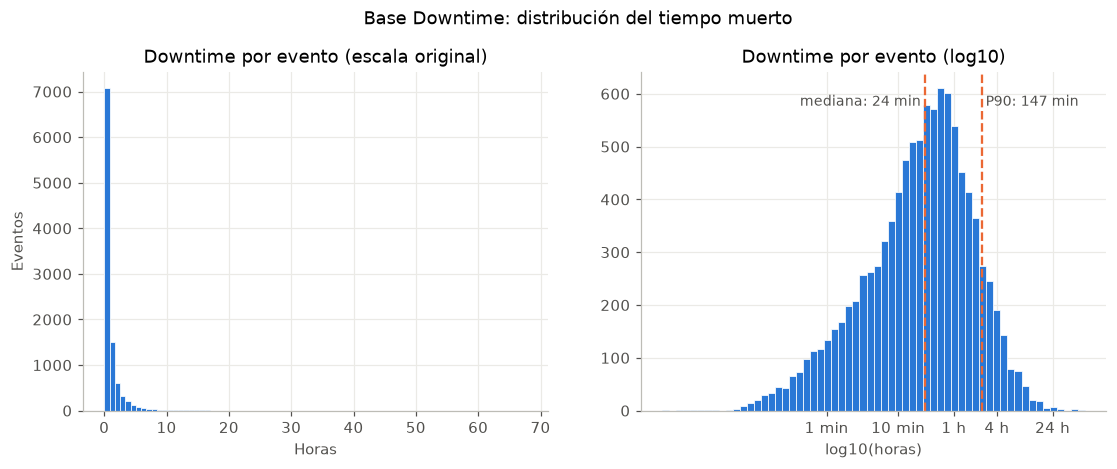

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
s = dt["Downtime"].dropna()
axes[0].hist(s, bins=80, color=AZUL, edgecolor="white", linewidth=0.5)
axes[0].set_title("Downtime por evento (escala original)")
axes[0].set_xlabel("Horas"); axes[0].set_ylabel("Eventos")
axes[1].hist(np.log10(s[s > 0]), bins=60, color=AZUL, edgecolor="white", linewidth=0.5)
for q, lab, ha in [(s.median(), "mediana", "right"), (s.quantile(.9), "P90", "left")]:
    axes[1].axvline(np.log10(q), color=NARANJA, linewidth=1.5, linestyle="--")
    axes[1].text(np.log10(q), axes[1].get_ylim()[1] * 0.9, f" {lab}: {q*60:,.0f} min ", color=GRIS, fontsize=9, ha=ha)
axes[1].set_title("Downtime por evento (log10)")
axes[1].set_xlabel("log10(horas)")
ticks = [1/60, 10/60, 1, 4, 24]
axes[1].set_xticks(np.log10(ticks)); axes[1].set_xticklabels(["1 min", "10 min", "1 h", "4 h", "24 h"])
fig.suptitle("Base Downtime: distribución del tiempo muerto", y=1.02)
guardar(fig, "01_hist_downtime"); plt.show()

La escala logarítmica permite observar mejor las duraciones pequeñas y la cola de eventos largos. Una forma más simétrica después de transformar no demuestra que los datos sigan una distribución lognormal.

### 2.4 Boxplots

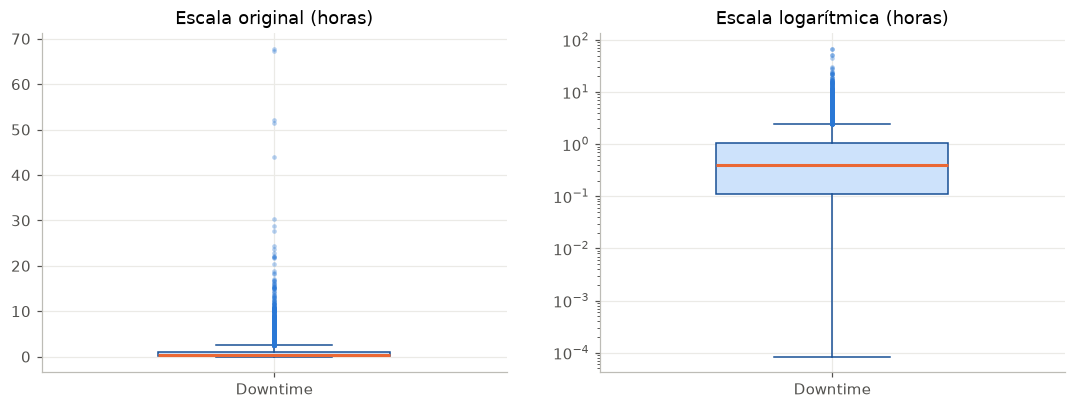

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data_box = [dt["Downtime"].dropna()]
labels_box = ["Downtime"]
bp_kw = dict(patch_artist=True, widths=0.5, medianprops=dict(color=NARANJA, linewidth=2),
             boxprops=dict(facecolor="#cde2fb", edgecolor=AZUL_OSC), whiskerprops=dict(color=AZUL_OSC),
             capprops=dict(color=AZUL_OSC), flierprops=dict(marker="o", markersize=3, markerfacecolor=AZUL, markeredgecolor="none", alpha=0.35))
axes[0].boxplot(data_box, tick_labels=labels_box, **bp_kw)
axes[0].set_title("Escala original (horas)")

axes[1].boxplot(data_box, tick_labels=labels_box, **bp_kw)
axes[1].set_yscale("log")
axes[1].set_title("Escala logarítmica (horas)")
guardar(fig, "03_boxplots"); plt.show()

Los boxplots muestran las mismas duraciones en escala original y logarítmica. Los puntos fuera de los bigotes son candidatos a revisión, no errores confirmados.

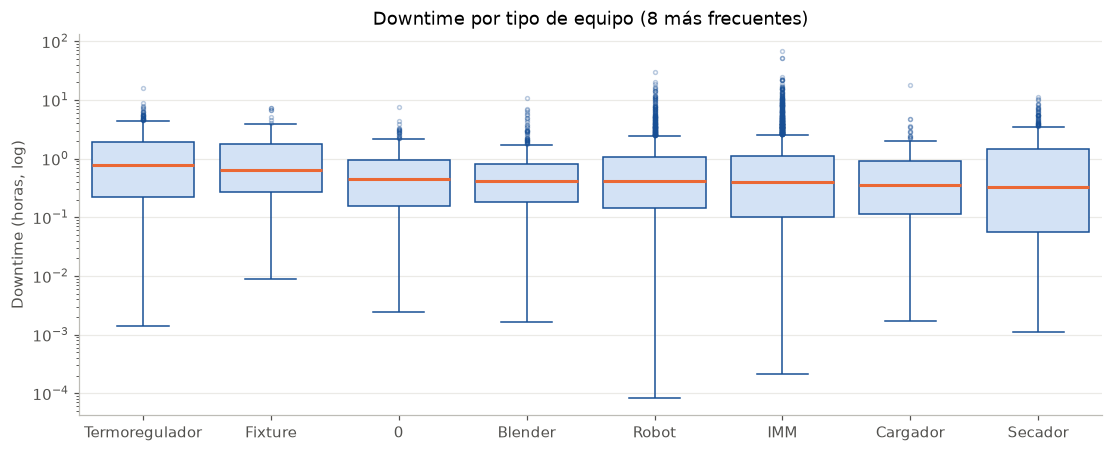

In [17]:
top_eq = dt["Eq Type 26"].value_counts().head(8).index
sub = dt[dt["Eq Type 26"].isin(top_eq)]
orden = sub.groupby("Eq Type 26", sort=False)["Downtime"].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(12, 4.5))
sns.boxplot(data=sub, x="Eq Type 26", y="Downtime", order=orden, color="#cde2fb", linecolor=AZUL_OSC,
            medianprops=dict(color=NARANJA, linewidth=2), flierprops=dict(marker="o", markersize=2.5, alpha=0.3), ax=ax)
ax.set_yscale("log"); ax.set_xlabel(""); ax.set_ylabel("Downtime (horas, log)")
ax.set_title("Downtime por tipo de equipo (8 más frecuentes)")
guardar(fig, "04_box_downtime_eqtype"); plt.show()

Se comparan los ocho tipos más frecuentes de Eq Type 26. El código 0 se conserva como categoría pendiente de validación y no debe interpretarse como un tipo de equipo confirmado. Las comparaciones excluyen registros sin tipo de equipo.

### 2.5 Valores atípicos

Se comparan umbrales superiores IQR en escala original y logarítmica, y un criterio bilateral de |z| > 3 sobre el logaritmo. Son criterios distintos de detección; ninguno confirma errores ni justifica eliminarlos automáticamente.

In [18]:
def outliers(serie, nombre):
    s = serie.dropna()
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lim_iqr = q3 + 1.5 * iqr
    ls = np.log(s[s > 0]); lq1, lq3 = ls.quantile([.25, .75]); liqr = lq3 - lq1
    lim_log = np.exp(lq3 + 1.5 * liqr)
    z = np.abs(stats.zscore(ls))
    return pd.Series({
        "n": s.size, "Q1": q1, "Q3": q3, "IQR": iqr, "límite sup. IQR": lim_iqr,
        "outliers IQR": (s > lim_iqr).sum(), "% IQR": (s > lim_iqr).mean() * 100,
        "límite sup. IQR (log)": lim_log, "outliers IQR log": (s > lim_log).sum(), "% IQR log": (s > lim_log).mean() * 100,
        "outliers |z|>3 (log)": (z > 3).sum(), "> 24 h": (s > 24).sum(),
    }, name=nombre)

tabla_out = pd.DataFrame({"Downtime (base Downtime)": outliers(dt["Downtime"], "Downtime (base Downtime)")}).T
display(tabla_out)

,n,Q1,Q3,IQR,límite sup. IQR,outliers IQR,% IQR,límite sup. IQR (log),outliers IQR log,% IQR log,outliers |z|>3 (log),> 24 h
Downtime (base Downtime),"10,166.000",0.109,1.052,0.943,2.465,"1,009.000",9.925,31.471,5.000,0.049,36.000,9.000


Los resultados muestran cuánto cambia la detección al transformar la escala. Los criterios IQR de esta tabla solo señalan la cola superior; el criterio z puede señalar ambas colas. No se eliminan observaciones.

In [19]:
s = dt["Downtime"].dropna().sort_values(ascending=False)
lim = tabla_out.loc["Downtime (base Downtime)", "límite sup. IQR"]
print(f"Eventos outlier (IQR) = {(s > lim).mean():.1%} de los eventos y acumulan {s[s > lim].sum() / s.sum():.1%} de las horas de paro.")
print(f"Top 1% de eventos acumula {s.head(int(len(s)*0.01)).sum() / s.sum():.1%} de las horas de paro.")
cols = ["Equipo", "Eq Type 26", "Opened", "Downtime", "Reason", "ISSUE 13", "Description 9"]
print("\n10 eventos con mayor downtime:")
display(dt.sort_values("Downtime", ascending=False)[cols].head(10))

Eventos outlier (IQR) = 9.9% de los eventos y acumulan 52.8% de las horas de paro.
Top 1% de eventos acumula 15.4% de las horas de paro.

10 eventos con mayor downtime:


,Equipo,Eq Type 26,Opened,Downtime,Reason,ISSUE 13,Description 9
38,Charros,Foil Feeder,2026-08-21 15:25:35.380,67.825,CAMBIO DE MODELO - FALLA MANTENIMIENTO,Servicios Varios,Favor de revisar foil feeder no prende
107,Hidalgo,IMM,2026-08-15 15:57:13.980,67.407,MANTENIMIENTO - MANTTO. CORRECTIVO,Servicios Varios,Rectificar camisa
6286,Nayarit,IMM,2025-08-02 17:44:30.347,51.999,MANTENIMIENTO - MANTTO. CORRECTIVO,Calibration Parameter Modification,Colocacion de calzas
392,Consentida,IMM,2026-07-26 07:29:59.647,51.540,MANTENIMIENTO - MANTTO. CORRECTIVO,Servicios Varios,Favor de revisar máquina no se mueve la prensa...
6284,Las Vegas,NaN,2025-08-02 21:49:09.417,43.925,CAMBIO DE MODELO - FALLA MANTENIMIENTO,NaN,NaN
10136,LaGloriosa,Robot,2025-01-03 13:13:15.543,30.235,CAMBIO DE MODELO - FALLA MANTENIMIENTO,EOAT Exchange,Favor de revisar alarma sobre intensidad motor...
4513,Yucatan,NaN,2025-11-18 09:02:05.370,28.693,CAMBIO DE MODELO - FALLA MANTENIMIENTO,NaN,NaN
6163,Lo Jefe,NaN,2025-08-11 09:37:34.090,27.666,MANTENIMIENTO - MANTTO. CORRECTIVO,NaN,NaN
5579,Preferida,IMM,2025-09-20 12:22:18.757,24.382,MANTENIMIENTO - MANTTO. CORRECTIVO,Clamping Piston Failure,Favor de chexsr prensa no habré platina gracias
6177,Mike Rover,NaN,2025-08-10 10:19:46.753,23.699,CAMBIO DE MODELO - FALLA MANTENIMIENTO,NaN,NaN


Los eventos largos pueden concentrar una proporción importante del tiempo acumulado. Se conservan y se propone validar su duración con la fuente. Las descripciones por sí solas no confirman que los tiempos sean correctos.

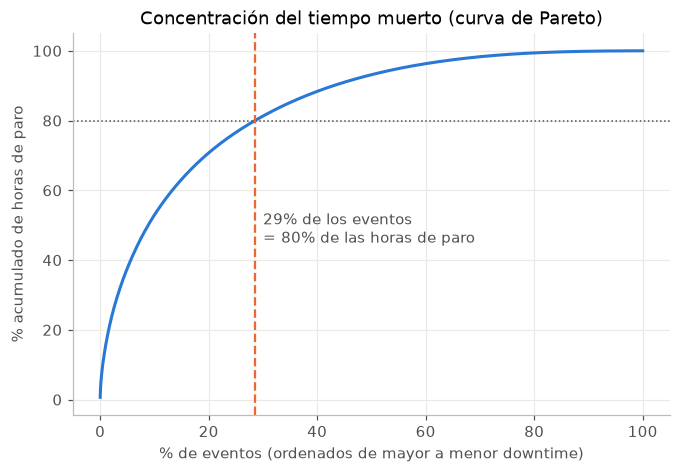

In [20]:

acum = s.cumsum() / s.sum()
pct_eventos = np.arange(1, len(s) + 1) / len(s)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(pct_eventos * 100, acum * 100, color=AZUL, linewidth=2)
k80 = np.searchsorted(acum.values, 0.8) + 1
ax.axhline(80, color=GRIS, linewidth=1, linestyle=":"); ax.axvline(k80 / len(s) * 100, color=NARANJA, linewidth=1.5, linestyle="--")
ax.text(k80 / len(s) * 100 + 1.5, 45, f"{k80/len(s):.0%} de los eventos\n= 80% de las horas de paro", color=GRIS)
ax.set_xlabel("% de eventos (ordenados de mayor a menor downtime)"); ax.set_ylabel("% acumulado de horas de paro")
ax.set_title("Concentración del tiempo muerto (curva de Pareto)")
guardar(fig, "05_pareto_eventos"); plt.show()

La curva ordena los eventos de mayor a menor duración y muestra qué proporción reúne el 80 % de las horas. Se trata de concentración dentro de la muestra, no de una relación causal.

### 2.6 Variables categóricas

Para cada variable categórica vemos cuántas categorías tiene, qué porcentaje viene vacío, cuál es la más común (moda) y cuántas categorías hacen falta para cubrir el 80 % de los registros.

In [21]:
cat_dt = ["Reason", "Equipo", "Eq Type 26", "Sub system 27", "ISSUE 13", "Device 28", "2nd class 29", "Corrective", "Brand", "Model"]
def card(df, cols, base):
    filas = []
    for c in cols:
        vc = df[c].value_counts()
        filas.append({"base": base, "variable": c, "categorías": df[c].nunique(), "% faltante": df[c].isna().mean() * 100,
                      "moda": vc.index[0], "% moda": vc.iloc[0] / df[c].notna().sum() * 100,
                      "categorías para 80%": int(np.searchsorted((vc.cumsum() / vc.sum()).values, 0.8) + 1)})
    return pd.DataFrame(filas)
tabla_card = card(dt, cat_dt, "Downtime")
display(tabla_card)

,base,variable,categorías,% faltante,moda,% moda,categorías para 80%
0,Downtime,Reason,4,0.000,MANTENIMIENTO - MANTTO. CORRECTIVO,77.614,2
1,Downtime,Equipo,92,0.000,LaBarranca,5.095,53
2,Downtime,Eq Type 26,26,17.537,IMM,51.038,3
3,Downtime,Sub system 27,28,17.537,0,39.134,4
4,Downtime,ISSUE 13,95,17.547,0,19.110,19
5,Downtime,Device 28,561,12.305,Validation,7.391,112
6,Downtime,2nd class 29,96,13.268,NOT CORRECTIVE,13.178,15
7,Downtime,Corrective,3,12.373,Corrective,86.609,1
8,Downtime,Brand,20,14.665,NISSEI,26.602,6
9,Downtime,Model,88,15.786,S5-25 S3 AXIAL,10.360,31


Los faltantes de esta tabla corresponden a NaN. Los ceros se cuentan como categorías mientras se verifica su significado. Las frecuencias y la moda se calculan sobre valores no faltantes; por ello los porcentajes no siempre usan como denominador todas las filas.

Función para las gráficas de frecuencia (muestra las categorías principales y agrupa el resto en "Otras").

In [22]:
def barras(ax, serie, titulo, top=12, color=AZUL):
    vc = serie.value_counts()
    otros = vc.iloc[top:].sum()
    vc = vc.head(top)
    if otros > 0:
        vc = pd.concat([vc, pd.Series({"Otras": otros})])
    vc = vc[::-1]
    ax.barh(vc.index.astype(str), vc.values, color=[GRIS if i == "Otras" else color for i in vc.index], height=0.7)
    tot = serie.notna().sum()
    for y, v in enumerate(vc.values):
        ax.text(v, y, f" {v:,} ({v/tot:.0%})", va="center", fontsize=8.5, color=GRIS)
    ax.set_title(titulo); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, vc.max() * 1.25)

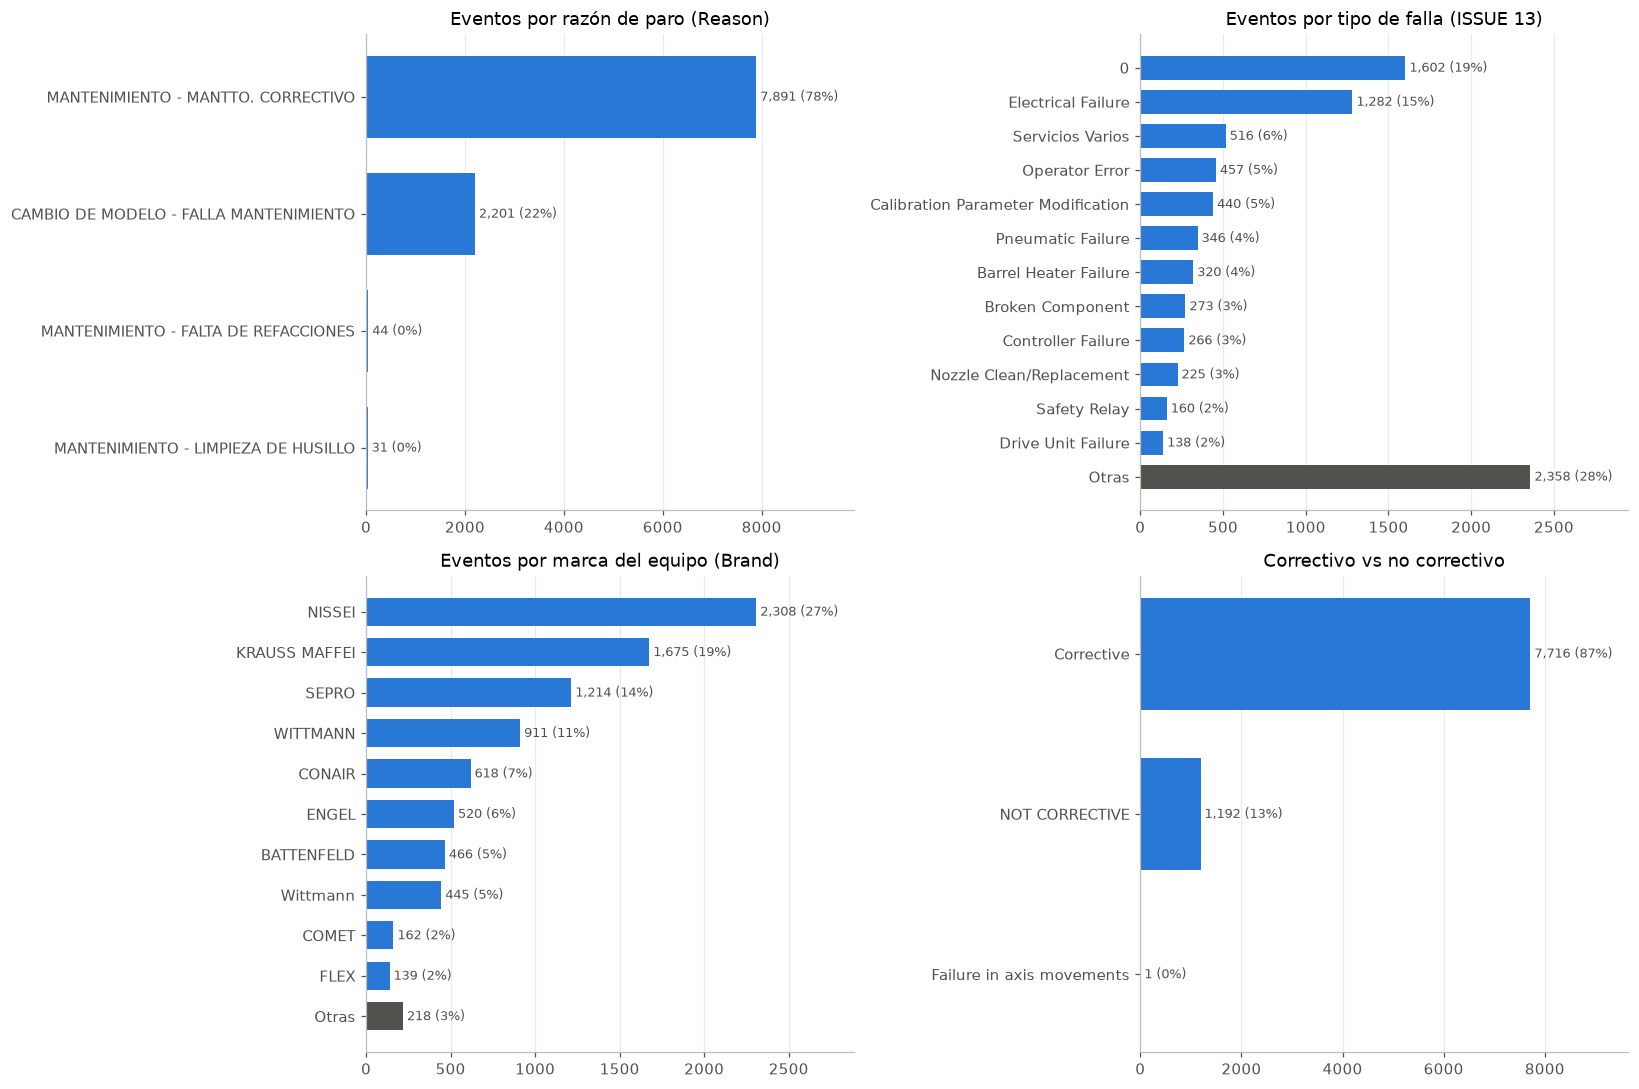

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
barras(axes[0, 0], dt["Reason"], "Eventos por razón de paro (Reason)", top=5)
barras(axes[0, 1], dt["ISSUE 13"], "Eventos por tipo de falla (ISSUE 13)", top=12)
barras(axes[1, 0], dt["Brand"], "Eventos por marca del equipo (Brand)", top=10)
barras(axes[1, 1], dt["Corrective"], "Correctivo vs no correctivo", top=3)
fig.tight_layout(); guardar(fig, "08_barras_downtime"); plt.show()

Las barras muestran frecuencias entre valores no faltantes de cada variable. Se conservan el código 0 de ISSUE 13 y la etiqueta inesperada de Corrective para hacer visibles los problemas pendientes. Las marcas solo tienen limpieza de espacios; pueden persistir variantes de mayúsculas.

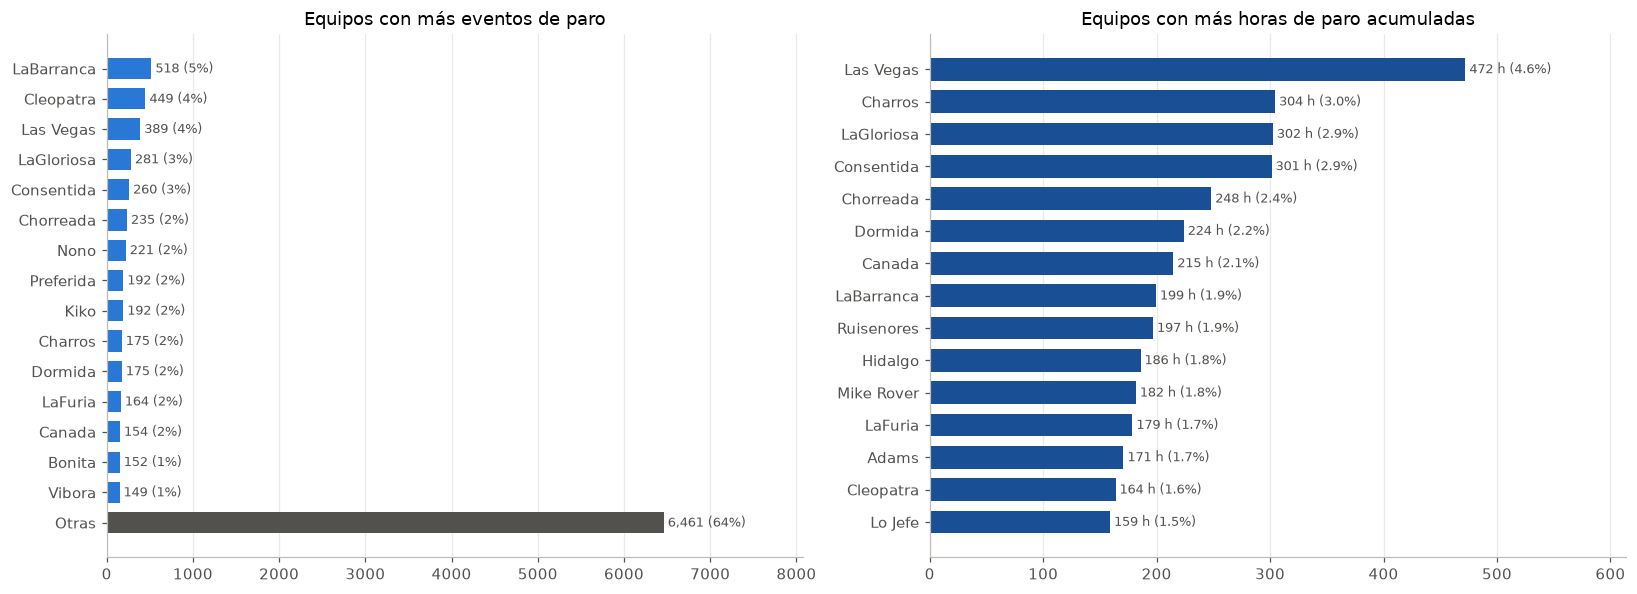

55 de 92 equipos (60%) juntan el 80% de las horas de paro.


In [24]:
horas_eq = dt.groupby("Equipo")["Downtime"].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
barras(axes[0], dt["Equipo"], "Equipos con más eventos de paro", top=15)
h = horas_eq.head(15)[::-1]
axes[1].barh(h.index, h.values, color=AZUL_OSC, height=0.7)
for y, v in enumerate(h.values):
    axes[1].text(v, y, f" {v:,.0f} h ({v/horas_eq.sum():.1%})", va="center", fontsize=8.5, color=GRIS)
axes[1].set_title("Equipos con más horas de paro acumuladas"); axes[1].grid(axis="y", visible=False); axes[1].set_xlim(0, h.max() * 1.3)
fig.tight_layout(); guardar(fig, "09_pareto_equipos"); plt.show()
n80 = np.searchsorted((horas_eq.cumsum() / horas_eq.sum()).values, 0.8) + 1
print(f"{n80} de {len(horas_eq)} equipos ({n80/len(horas_eq):.0%}) juntan el 80% de las horas de paro.")

El orden por frecuencia de eventos puede diferir del orden por horas acumuladas. Los conteos incluyen todas las filas; las sumas de downtime excluyen la duración no numérica convertida a NaN.

### 2.7 Distribución en el tiempo

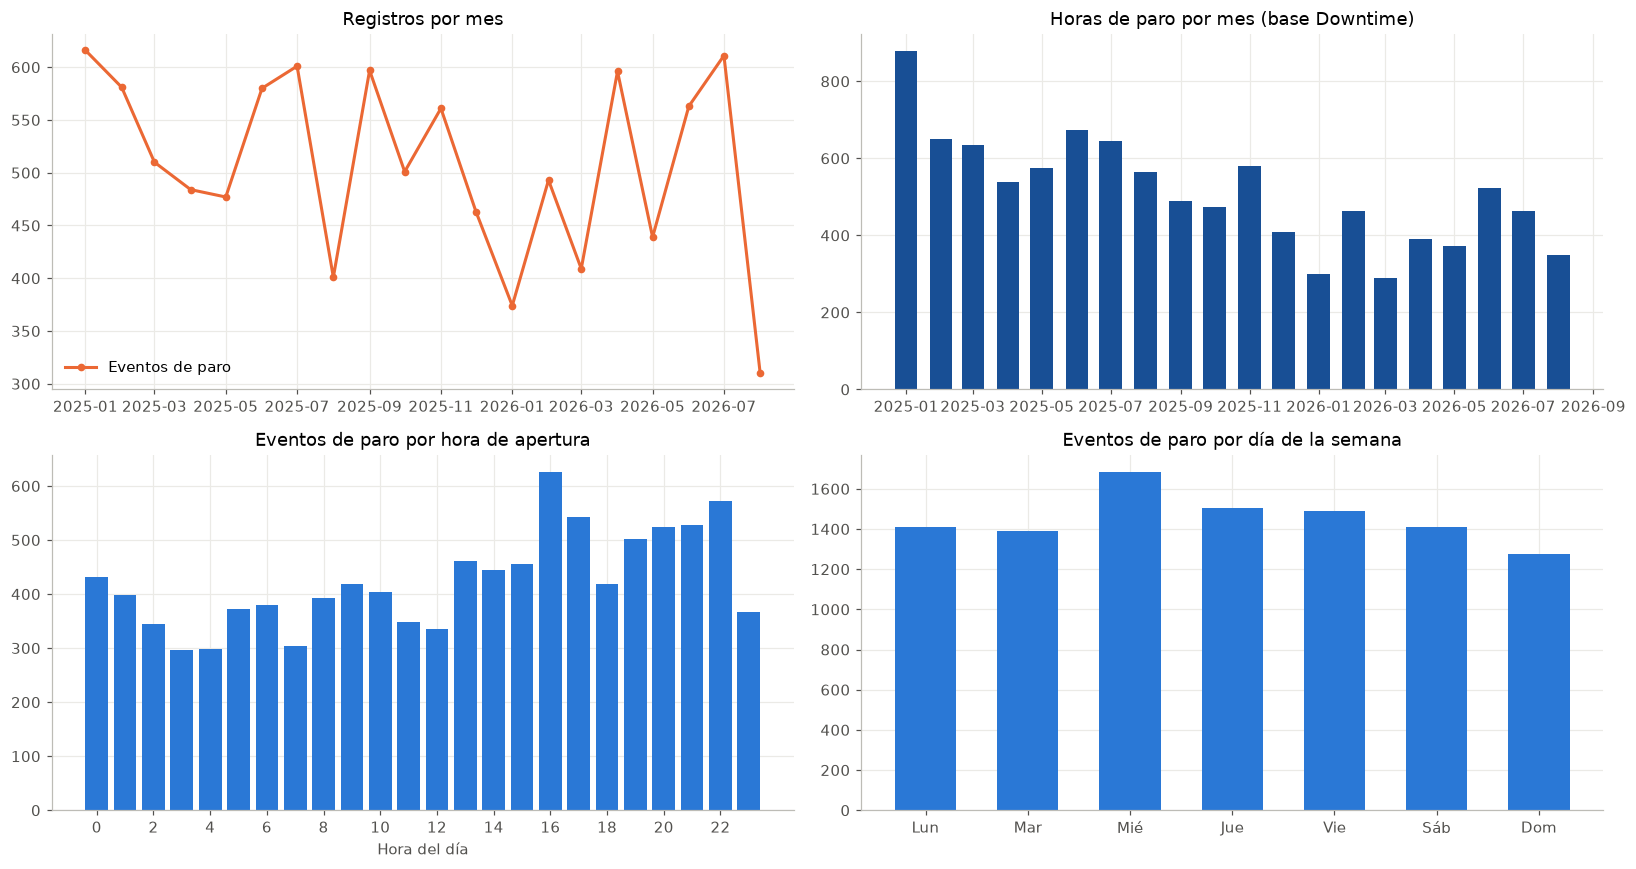

Agosto de 2026 viene incompleto en la base de Downtime.


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
m_dt = dt.groupby("anio_mes").size()
axes[0, 0].plot(m_dt.index.to_timestamp(), m_dt.values, color=NARANJA, linewidth=2, marker="o", markersize=4, label="Eventos de paro")
axes[0, 0].set_title("Registros por mes"); axes[0, 0].legend(frameon=False)
h_dt = dt.groupby("anio_mes")["Downtime"].sum()
axes[0, 1].bar(h_dt.index.to_timestamp(), h_dt.values, width=20, color=AZUL_OSC)
axes[0, 1].set_title("Horas de paro por mes (base Downtime)")
hr = dt["hora"].value_counts().sort_index()
axes[1, 0].bar(hr.index, hr.values, color=AZUL, width=0.8); axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].set_title("Eventos de paro por hora de apertura"); axes[1, 0].set_xlabel("Hora del día")
ds = dt["dia_semana"].value_counts().reindex(dias)
axes[1, 1].bar(ds.index, ds.values, color=AZUL, width=0.6); axes[1, 1].set_title("Eventos de paro por día de la semana")
fig.tight_layout(); guardar(fig, "10_temporal"); plt.show()
print("Agosto de 2026 viene incompleto en la base de Downtime.")

Las gráficas representan conteos y horas observados, no tasas de falla ajustadas por horas de operación. Agosto de 2026 está incompleto. Las diferencias por hora o día pueden depender de turnos, actividad y captura; no demuestran mayor riesgo de falla.

### 2.8 Forma de la distribución del downtime

,variable,asimetría,curtosis,D'Agostino p-valor,Shapiro (n=5000) p-valor
0,Downtime (horas),11.533,251.319,0.000,0.000
1,log(Downtime),-0.568,0.245,0.000,0.000


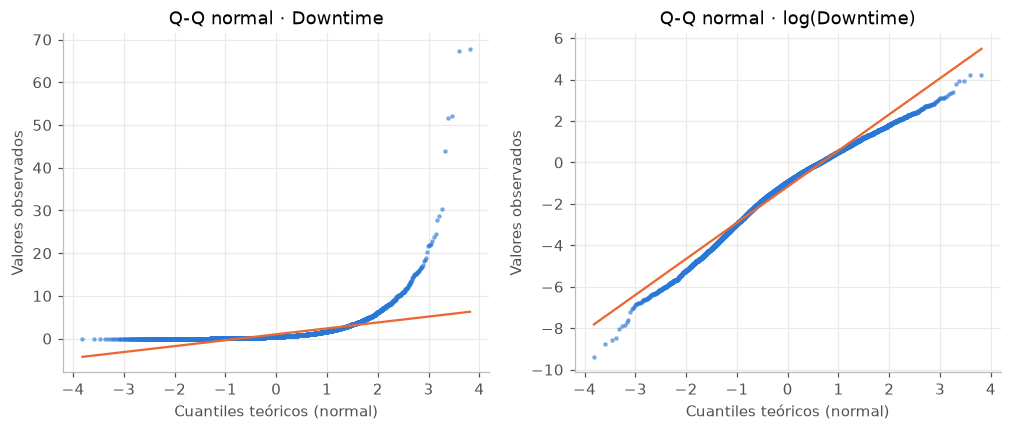

In [26]:
s = dt["Downtime"].dropna(); s = s[s > 0]
filas = []
for nombre, x in [("Downtime (horas)", s), ("log(Downtime)", np.log(s))]:
    muestra = x.sample(5000, random_state=42) if len(x) > 5000 else x
    filas.append({"variable": nombre, "asimetría": x.skew(), "curtosis": x.kurt(),
                  "D'Agostino p-valor": stats.normaltest(x).pvalue, "Shapiro (n=5000) p-valor": stats.shapiro(muestra).pvalue})
display(pd.DataFrame(filas))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(s, dist="norm", plot=axes[0]); axes[0].set_title("Q-Q normal · Downtime")
stats.probplot(np.log(s), dist="norm", plot=axes[1]); axes[1].set_title("Q-Q normal · log(Downtime)")
for ax in axes:
    ax.set_xlabel("Cuantiles teóricos (normal)"); ax.set_ylabel("Valores observados")
    ax.get_lines()[0].set(color=AZUL, markersize=2, alpha=0.5); ax.get_lines()[1].set(color=NARANJA)
guardar(fig, "11_qqplot"); plt.show()

Las pruebas de normalidad rechazan en los dos casos, lo cual es esperable con más de 10 mil datos. Aun así, al sacar logaritmo la asimetría baja de 11.5 a menos 0.57 y la curtosis de 251 a 0.25. En el Q-Q plot del logaritmo los puntos siguen casi la línea recta y solo se separan en los extremos, por los paros de segundos a la izquierda y porque la cola derecha es un poco más corta que la de una normal.

### 2.9 Hallazgos y limitaciones

se analizaron 10,166 duraciones numéricas y se conservaron los 10,167 eventos. La mediana es 0.394 horas (23.62 minutos), la media 1.010 horas y el percentil 90 es 2.447 horas. La duración máxima es 67.825 horas. El umbral superior IQR original identifica 1,009 eventos (9.93 %); el umbral superior IQR logarítmico identifica cinco. Son señales de revisión y no eliminaciones.

La duración presenta una cola derecha larga y conviene describirla con mediana y percentiles además de la media. Se mantienen los valores atípicos para revisión. La normalización evita fragmentar algunas categorías, pero permanecen faltantes, ceros y etiquetas ambiguas.

Los eventos no equivalen a tickets únicos. Para predecir duración al abrir un ticket, debe verificarse que los predictores estén disponibles en ese momento. Las clasificaciones asignadas tras el diagnóstico o cierre pueden generar fuga de información. No se afirma que todos los tickets estén abiertos.


# 3.0 Analisis de correlación

Primero limpiamos los parametros que son duplicados

In [39]:
df = pd.read_excel("Datos/Resumen Downtime Current.xlsx",  sheet_name="2024")

# Checamos las variables que son numéricas y las que no lo son
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

print("Columnas numéricas:", numeric_columns)

non_numeric_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Columnas no numéricas:", non_numeric_columns)

Columnas numéricas: ['mes', 'Año', 'ss']
Columnas no numéricas: ['Equipo', 'Opened', 'Update', 'Reason', 'Ticket', 'Downtime', 'ISSUE 13', 'Description 9', 'Work Description (Close Details) 17', 'Dia', 'Semana', 'Equipo 26', 'Sub system 27', 'EQ2', 'Clase 13', 'DD', 'Device 28', 'Fecha completa', '2nd class 29', 'Corrective', 'Class2 29', 'Eq Type 26', 'Automotive? As on Aug-2024', 'Brand', 'Model']


Encontramos varibales que deberian ser de otro tipo pero estan como no numericas por ejemplo

Downtime

Otras que se podrian transformar

Semana viene con formato Año - semana 

In [40]:
# Convertimos la columna Downtime a numérica, forzando los errores a NaN
df['Downtime'] = pd.to_numeric(df['Downtime'], errors='coerce')

# Transformamos la columna semana para que sea de formano numero quitando el año - semana
df['Semana'] = df['Semana'].str.extract(r'(\d+)$')  # Extrae solo los dígitos al final de la cadena
df['Semana'] = pd.to_numeric(df['Semana'], errors='coerce')

Checamos columnas duplicadas

In [41]:
import pandas as pd
import numpy as np


exact_duplicates = []
# Convertimos temporalmente a string para comparar todas las columnas de forma uniforme
df_str = df.astype(str)
duplicated_mask = df_str.T.duplicated(keep=False)

if duplicated_mask.any():
    dup_cols = df_str.columns[duplicated_mask].tolist()
    # Agrupar columnas que son idénticas entre sí
    groups = {}
    for col in dup_cols:
        val_tuple = tuple(df_str[col])
        groups.setdefault(val_tuple, []).append(col)
    
    print("--- COLUMNAS IDÉNTICAS ---")
    for cols in groups.values():
        if len(cols) > 1:
            print(f"Grupo de idénticas: {cols}")
else:
    print("No se encontraron columnas idénticas.")


# Evalúa si dos columnas tienen exactamente la misma cantidad de categorías 
# y la combinación de ambas no genera nuevas subdivisiones (V de Cramér = 1.0)
def find_equivalent_columns(dataframe):
    cols = dataframe.columns
    redundant_pairs = []
    
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            col1, col2 = cols[i], cols[j]
            
            # Solo comparar si ambas tienen el mismo número de valores únicos
            if dataframe[col1].nunique(dropna=False) == dataframe[col2].nunique(dropna=False):
                # Si el número de combinaciones únicas es igual al número de categorías individuales, son equivalentes 1:1
                combined_uniques = dataframe.groupby([col1, col2], dropna=False).ngroups
                if combined_uniques == dataframe[col1].nunique(dropna=False):
                    redundant_pairs.append((col1, col2))
                    
    return redundant_pairs

redundant = find_equivalent_columns(df)

print("\n--- COLUMNAS CON REDUNDANCIA LÓGICA ---")
if redundant:
    for pair in redundant:
        print(f"Las columnas '{pair[0]}' y '{pair[1]}' contienen la misma información codificada de forma distinta.")
else:
    print("No se encontraron columnas con mapeo 1 a 1.")


--- COLUMNAS IDÉNTICAS ---
Grupo de idénticas: ['Opened', 'Dia']
Grupo de idénticas: ['ISSUE 13', 'Clase 13']

--- COLUMNAS CON REDUNDANCIA LÓGICA ---
Las columnas 'Opened' y 'Dia' contienen la misma información codificada de forma distinta.
Las columnas 'ISSUE 13' y 'Clase 13' contienen la misma información codificada de forma distinta.


Borramos las columnas dia y ISSUE 13, ya que contienen la misma información que Opened y Clase 13

In [42]:
# Borramos la columna dia y ISSUE 13
df.drop(columns=['Dia', 'ISSUE 13'], inplace=True)

# Convertimos la columna opened y update a tipo fecha
df['Opened'] = pd.to_datetime(df['Opened'], errors='coerce')
df['Update'] = pd.to_datetime(df['Update'], errors='coerce')

# Borramos la column 'Automotive? As on Aug-2024' por que tiene solo un valor
df.drop(columns=['Automotive? As on Aug-2024'], inplace=True, errors='ignore')

Matriz inicial de correlaciones entre variables categoricas y su influencia en downtime

<>:68: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:68: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\ngedg\AppData\Local\Temp\ipykernel_46120\3039528515.py:68: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  axes[0].set_title('Top Variables Categóricas que influyen en Downtime ($\eta$)')
C:\Users\ngedg\AppData\Local\Temp\ipykernel_46120\3039528515.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eta.head(12), x='Eta (Impacto en Downtime)', y='Variable', ax=axes[0], palette='Blues_r')


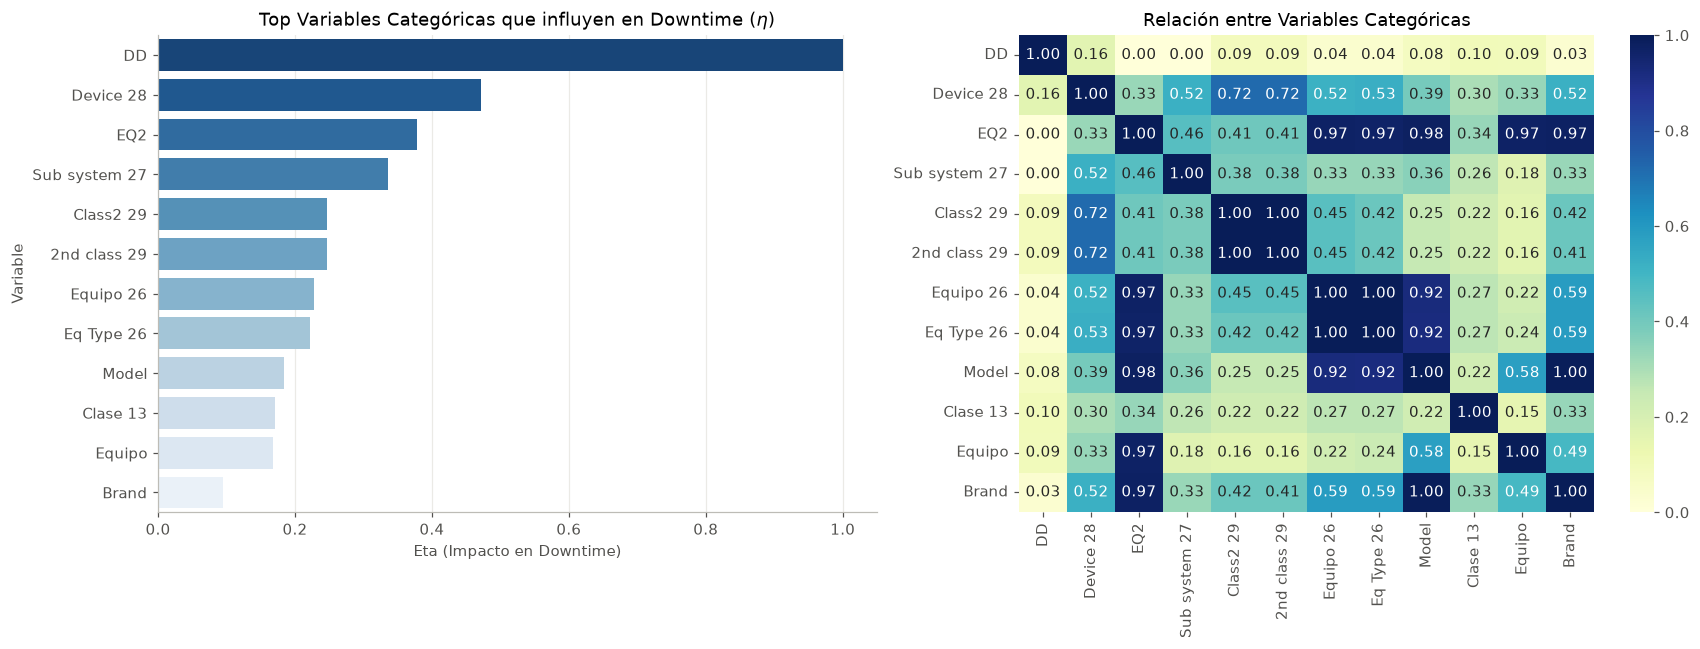

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

cat_cols = [
    'Equipo', 'Reason', 'Equipo 26', 'Sub system 27', 
    'EQ2', 'Clase 13', 'DD', 'Device 28', '2nd class 29', 'Corrective', 
    'Class2 29', 'Eq Type 26', 'Brand', 'Model'
]

# Filtrar solo las que existen en el DataFrame y convertirlas a string
cat_cols = [col for col in cat_cols if col in df.columns]
for col in cat_cols:
    df[col] = df[col].astype(str)


def correlation_ratio(categories, measurements):
    fcat = pd.Categorical(categories)
    cat_num = fcat.codes
    y = np.asarray(measurements)
    
    mask = ~np.isnan(y) & (cat_num != -1)
    y, cat_num = y[mask], cat_num[mask]
    
    sstr = sum((y - y.mean()) ** 2)
    if sstr == 0:
        return 0
    bg = [len(y[cat_num == c]) * (y[cat_num == c].mean() - y.mean()) ** 2 for c in np.unique(cat_num)]
    return np.sqrt(sum(bg) / sstr)

# Calcular Eta para cada categórica contra Downtime
eta_results = {col: correlation_ratio(df[col], df['Downtime']) for col in cat_cols}
df_eta = pd.DataFrame(list(eta_results.items()), columns=['Variable', 'Eta (Impacto en Downtime)'])
df_eta = df_eta.sort_values(by='Eta (Impacto en Downtime)', ascending=False)


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    if n == 0:
        return 0
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else 0


# Seleccionar las top 12 categóricas con mayor impacto para construir la matriz
top_cats = df_eta['Variable'].head(12).tolist()

cramer_matrix = pd.DataFrame(index=top_cats, columns=top_cats, dtype=float)
for col1 in top_cats:
    for col2 in top_cats:
        cramer_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])



fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Impacto sobre la variable objetivo (Downtime)
sns.barplot(data=df_eta.head(12), x='Eta (Impacto en Downtime)', y='Variable', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top Variables Categóricas que influyen en Downtime ($\eta$)')

# Gráfico 2: Matriz de Asociación entre Variables Categóricas
sns.heatmap(cramer_matrix, annot=True, cmap='YlGnBu', vmin=0, vmax=1, fmt=".2f", ax=axes[1])
axes[1].set_title('Relación entre Variables Categóricas')

plt.tight_layout()
plt.show()

Atravez de la grafica a la izquierda se puede observar que el valor de DD influye totalmente en el Eta, esto no deberia de ser así, por lo tanto se debe de excluir el valor de DD hasta saber con certeza que representa y si es relevante o no. A su vez, en la matriz C de Cramér podemos observar las relaciones entre variables categoricas, en esta se observa que hay multiples variables con relaciones de 1 o muy cercanas a 1 lo cual nos indica que representan lo mismo o tienen la misma información.

In [44]:
import pandas as pd

# Pares identificados con V de Cramér = 1.00 en la imagen
pairs_to_check = [
    ('Class2 29', '2nd class 29'),
    ('Equipo 26', 'Eq Type 26'),
    ('EQ2', 'Equipo 26')
]

for col1, col2 in pairs_to_check:
    if col1 in df.columns and col2 in df.columns:
        print(f"\n==========================================")
        print(f"COMPARA: '{col1}' vs '{col2}'")
        print(f"==========================================")
        
        # Muestra una tabla cruzada con conteo de coincidencias
        ct = pd.crosstab(df[col1].fillna('NULO'), df[col2].fillna('NULO'))
        print(ct.head(10))


COMPARA: 'Class2 29' vs '2nd class 29'
2nd class 29                      1  Barrel heater problems  Barrel heating problem  Barrel heating problems  Blender Pneumatic System failure  Blender control panel failure  \
Class2 29                                                                                                                                                                       
1                                 3                       0                       0                        0                                 0                              0   
Barrel heater problems            0                       1                       0                        0                                 0                              0   
Barrel heating problem            0                       0                       1                        0                                 0                              0   
Barrel heating problems           0                       0                

Con esto se puede observar que tienen casi la misma informacion con diferencias minimas entonces dropeamos la columna Class2 29, Eq Type 26 y EQ2 que es una mezcla entre modelo y equipo, las cuales ya son consideradas.

In [45]:
df = df.drop(columns=['Class2 29', 'Eq Type 26', 'EQ2'], errors='ignore')

<>:75: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:75: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\ngedg\AppData\Local\Temp\ipykernel_46120\2006499341.py:75: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  axes[0].set_title('Top Variables Categóricas que influyen en Downtime ($\eta^2$ %)')
C:\Users\ngedg\AppData\Local\Temp\ipykernel_46120\2006499341.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


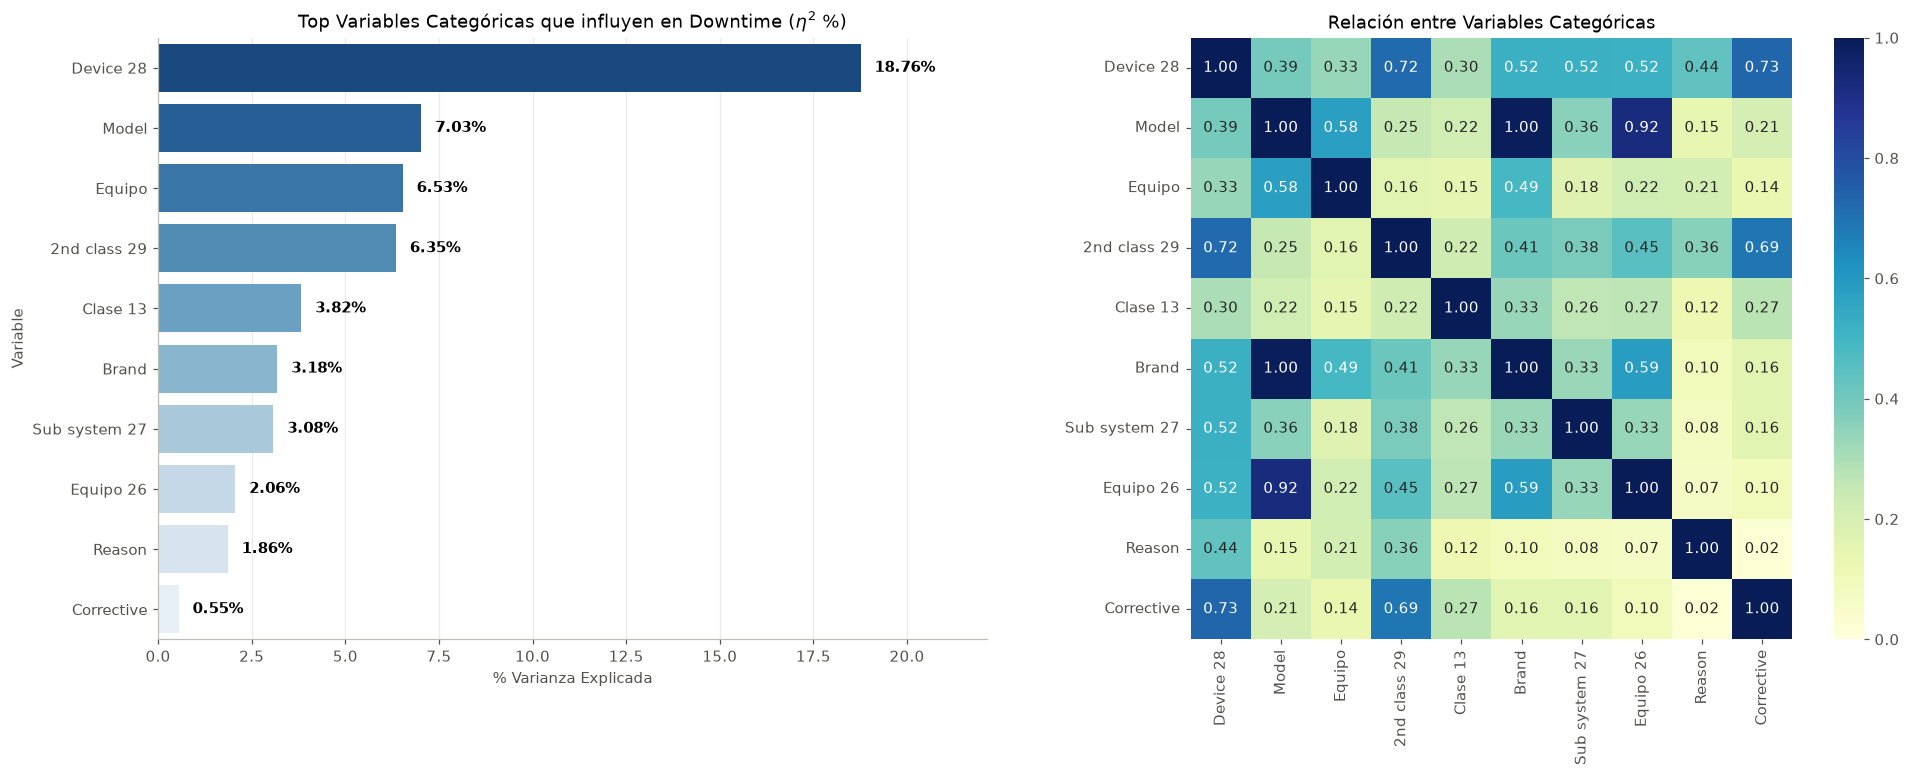

In [46]:
cat_cols = [
    'Equipo', 'Reason', 'Equipo 26', 'Sub system 27', 
    'Clase 13', 'Device 28', '2nd class 29', 'Corrective', 
    'Brand', 'Model'
]

# Filtrar existentes y convertir a string
cat_cols = [col for col in cat_cols if col in df.columns]
for col in cat_cols:
    df[col] = df[col].astype(str)

# Transformación logarítmica de Downtime
if 'Downtime' in df.columns:
    df['log_downtime'] = np.log1p(df['Downtime'])


def eta_squared(data, cat_var, num_var):
    clean_data = data[[cat_var, num_var]].dropna()
    groups = [group[num_var].values for _, group in clean_data.groupby(cat_var)]
    
    if len(groups) < 2:
        return np.nan
    
    overall_mean = clean_data[num_var].mean()
    sst = np.sum((clean_data[num_var] - overall_mean) ** 2)
    ssb = sum(len(g) * (np.mean(g) - overall_mean) ** 2 for g in groups)
    
    return (ssb / sst) * 100 if sst != 0 else 0

eta_list = []
for cat in cat_cols:
    eta_val = eta_squared(df, cat, 'log_downtime')
    if not np.isnan(eta_val):
        eta_list.append({
            'Variable': cat,
            'Eta_Squared (%)': eta_val
        })

df_eta_results = pd.DataFrame(eta_list).sort_values(by='Eta_Squared (%)', ascending=False)

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    if n == 0:
        return 0
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else 0

# Tomar las top categóricas ordenadas por su impacto Eta^2
top_cats = df_eta_results['Variable'].head(12).tolist()

cramer_matrix = pd.DataFrame(index=top_cats, columns=top_cats, dtype=float)
for col1 in top_cats:
    for col2 in top_cats:
        cramer_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])



fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Impacto sobre Downtime (Eta²)
sns.barplot(
    data=df_eta_results, 
    x='Eta_Squared (%)', 
    y='Variable', 
    ax=axes[0], 
    palette='Blues_r'
)
axes[0].set_title('Top Variables Categóricas que influyen en Downtime ($\eta^2$ %)')
axes[0].set_xlabel('% Varianza Explicada')

# Ajuste de escala X y etiquetas en las barras
max_val = df_eta_results['Eta_Squared (%)'].max()
axes[0].set_xlim(0, max_val * 1.18)
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(
        f'{width:.2f}%', 
        (width + (max_val * 0.02), p.get_y() + p.get_height() / 2.),
        ha='left', va='center', fontsize=10, fontweight='bold'
    )

# Gráfico 2: Matriz de Asociación V de Cramér
sns.heatmap(
    cramer_matrix, 
    annot=True, 
    cmap='YlGnBu', 
    vmin=0, 
    vmax=1, 
    fmt=".2f", 
    ax=axes[1],
    square=True
)
axes[1].set_title('Relación entre Variables Categóricas')

plt.tight_layout()
plt.show()

Atravez de la grafica de la izquiera se puede observar que el 18.76% del downtime esta relacionado con el tipo de Device 28 del cual es el ticket, a su vez se puede ver que el modelo y del equipo al cual pertenecen tambien tienen cierta infuencia en el downtime de la maquinaria. Sin embargo tambien se puede observar que el corrective, reason y el sub system 27 no tienen una gran relación. 

Observando la grafica de la derecha se puede observar que existen multiples variables con gran relación entre las variables categoricas, como el model con el brand las cuales aunque no tienen la misma información representan cosas muy similares. En cuanto a las variables que tienen alta asociación dentro del rango esperado destaca el device 28 con la 2nd class 29, lo cual nos indica que las partes especificas de los problemas estan fuertemente ligadas con los modos de falla.

--- CORRELACIÓN SPEARMAN (NUMÉRICA VS NUMÉRICA) ---
          Downtime    mes    Año     ss
Downtime     1.000 -0.081 -0.120 -0.003
mes         -0.081  1.000 -0.252  0.036
Año         -0.120 -0.252  1.000 -0.019
ss          -0.003  0.036 -0.019  1.000


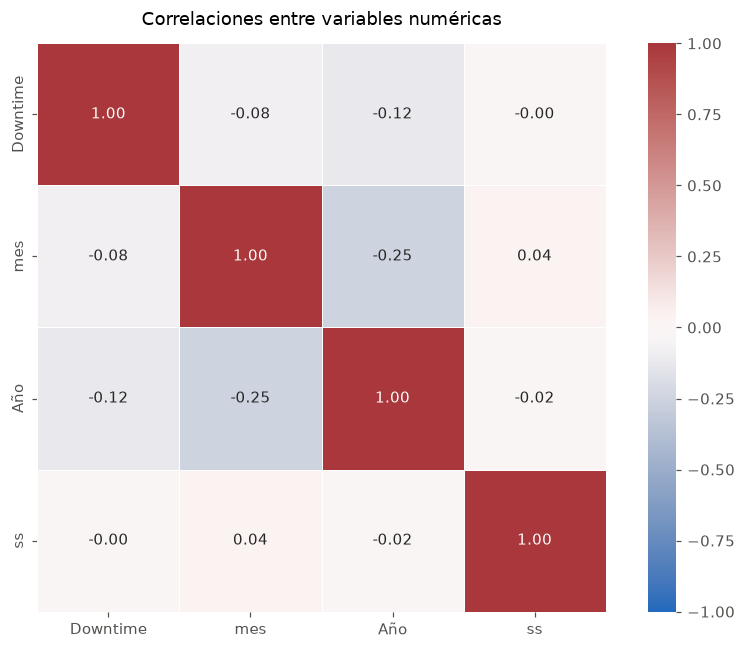

In [47]:
from scipy.stats import f_oneway

# Ajustar las columnas categóricas tras eliminar 'Dia' e 'ISSUE 13'
cat_cols = [
    'Equipo', 'Reason', 'Equipo 26', 'Sub system 27', 
    'Clase 13', 'DD', 'Device 28', '2nd class 29', 'Corrective', 
     'Brand', 'Model'
]
cat_cols = [col for col in cat_cols if col in df.columns]

# Identificar columnas numéricas
num_cols = ['Downtime', 'semana' , 'mes', 'Año', 'ss']
num_cols = [col for col in num_cols if col in df.columns]


# Usamos Spearman (detecta relaciones no lineales y es resistente a outliers)
spearman_corr = df[num_cols].corr(method='spearman')

print("--- CORRELACIÓN SPEARMAN (NUMÉRICA VS NUMÉRICA) ---")
print(spearman_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr, 
    annot=True, 
    cmap='vlag', 
    vmin=-1, 
    vmax=1, 
    fmt=".2f", 
    square=True,
    linewidths=0.5
)
plt.title('Correlaciones entre variables numéricas', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

Al revizar las correlaciones entre variables numericas, nos podemos dar cuenta que estas no tienen casi ninguna relación entre ellas. La relación mas relevante encontrada seria que el donwtieme tiene una relación negativa con el año, lo cual podria indicar que el downtime se reduce un poco cada año transcurrido.

--- PROMEDIO MENSUAL AJUSTADO POR AÑOS REGISTRADOS ---
nombre_mes  total_tickets  anios_presentes  promedio_tickets
       Ene            990                2           495.000
       Feb           1074                2           537.000
       Mar            919                2           459.500
       Abr           1080                2           540.000
       May            916                2           458.000
       Jun           1143                2           571.500
       Jul           1212                2           606.000
       Ago            711                2           355.500
       Sep            597                1           597.000
       Oct            501                1           501.000
       Nov            561                1           561.000
       Dic            463                1           463.000


C:\Users\ngedg\AppData\Local\Temp\ipykernel_46120\1972834793.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


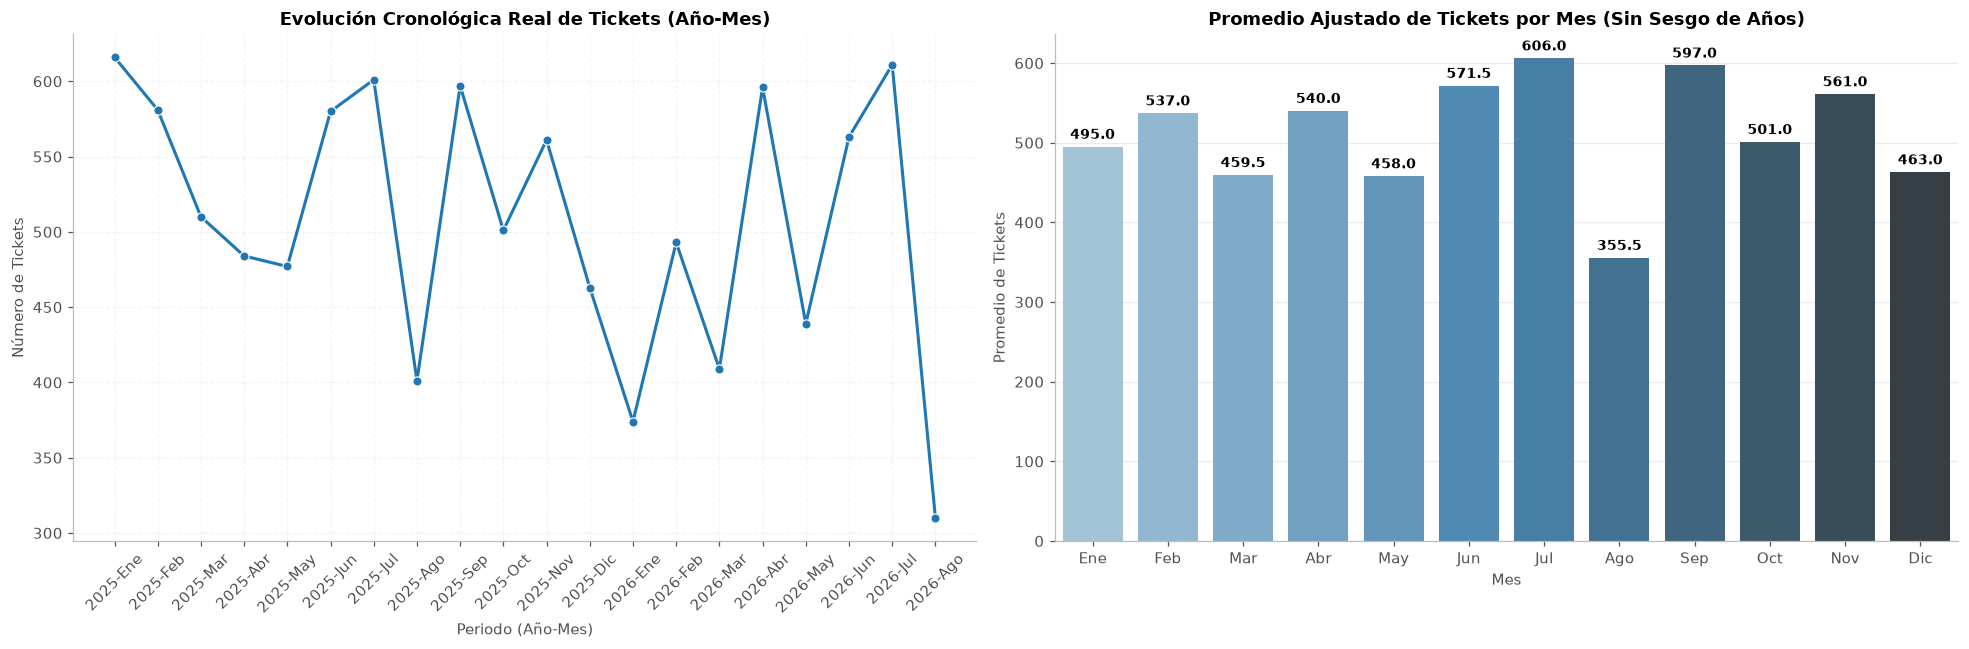

In [48]:


# Contar cuántos tickets hubo exactamente en cada combinación Año-Mes
df_tickets_periodo = df.groupby(['Año', 'mes']).size().reset_index(name='num_tickets')

# Mapeo de meses (1 al 12)
meses_map = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}
df_tickets_periodo['nombre_mes'] = df_tickets_periodo['mes'].map(meses_map)

# Crear etiqueta de periodo (ej. '2025-Ene') para la serie temporal real
df_tickets_periodo['periodo'] = df_tickets_periodo['Año'].astype(str) + '-' + df_tickets_periodo['nombre_mes']


# Agrupar por mes y calcular el promedio según los años presentes
df_promedio_mes = df_tickets_periodo.groupby(['mes', 'nombre_mes']).agg(
    total_tickets=('num_tickets', 'sum'),
    anios_presentes=('Año', 'nunique'),
    promedio_tickets=('num_tickets', 'mean')
).reset_index().sort_values(by='mes')

print("--- PROMEDIO MENSUAL AJUSTADO POR AÑOS REGISTRADOS ---")
print(df_promedio_mes[['nombre_mes', 'total_tickets', 'anios_presentes', 'promedio_tickets']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico A: Serie Temporal Cronológica (Año por Año)
sns.lineplot(
    data=df_tickets_periodo, 
    x='periodo', 
    y='num_tickets', 
    marker='o', 
    linewidth=2, 
    color='#1f77b4', 
    ax=axes[0]
)
axes[0].set_title('Evolución Cronológica Real de Tickets (Año-Mes)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Periodo (Año-Mes)', fontsize=10)
axes[0].set_ylabel('Número de Tickets', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfico B: Promedio de Tickets por Mes (Normalizado)
sns.barplot(
    data=df_promedio_mes, 
    x='nombre_mes', 
    y='promedio_tickets', 
    palette='Blues_d', 
    ax=axes[1]
)
axes[1].set_title('Promedio Ajustado de Tickets por Mes (Sin Sesgo de Años)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mes', fontsize=10)
axes[1].set_ylabel('Promedio de Tickets', fontsize=10)

# Etiquetar barras con el valor promedio exacto
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(
        f'{height:.1f}', 
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points'
    )

plt.tight_layout()
plt.show()

Atravez de esta grafica se puede observar como se relaciona la frecuencia de tickets respecto al mes, en este caso no se puede encontrar un patron especifico, la dsitribución esta mas o menos igual con excepción del mes de agosto donde se registra un numero menor de tiquets al igual que el mes de diciembre el cual tambien tiene menos tiquets que el resto de los meses, lo cual se puede deber al periodo vacacional.

C:\Users\ngedg\AppData\Local\Temp\ipykernel_46120\4168472755.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


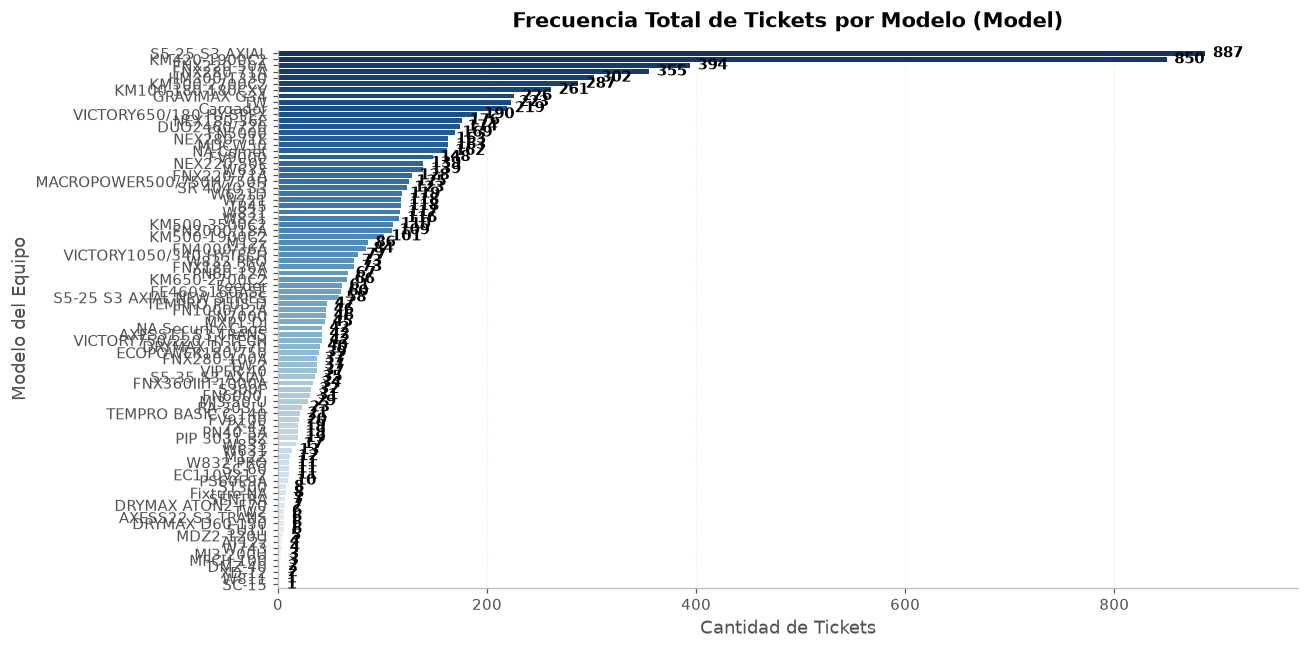

In [49]:

# Agrupar y contar la frecuencia de tickets por cada Modelo
df_model_freq = df['Model'].value_counts().reset_index()
df_model_freq.columns = ['Model', 'frecuencia']

# 2. Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_model_freq, 
    x='frecuencia', 
    y='Model', 
    palette='Blues_r'
)

# Personalizar títulos y etiquetas
plt.title('Frecuencia Total de Tickets por Modelo (Model)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Tickets', fontsize=12)
plt.ylabel('Modelo del Equipo', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, axis='x')

# Añadir las etiquetas con el valor exacto sobre cada barra
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}', 
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', 
        va='center', 
        fontsize=10, 
        fontweight='bold', 
        xytext=(5, 0), 
        textcoords='offset points'
    )

# Ajustar márgenes para dar espacio a los números
plt.xlim(0, df_model_freq['frecuencia'].max() * 1.1)
plt.tight_layout()
plt.show()

Atravez de esta grafica podemos observar la frecuencia de tikets de cada modelo del equipo, lo cual nos da a conocer que una gran cantidad de modelost tienen una poca catidad de tickets.

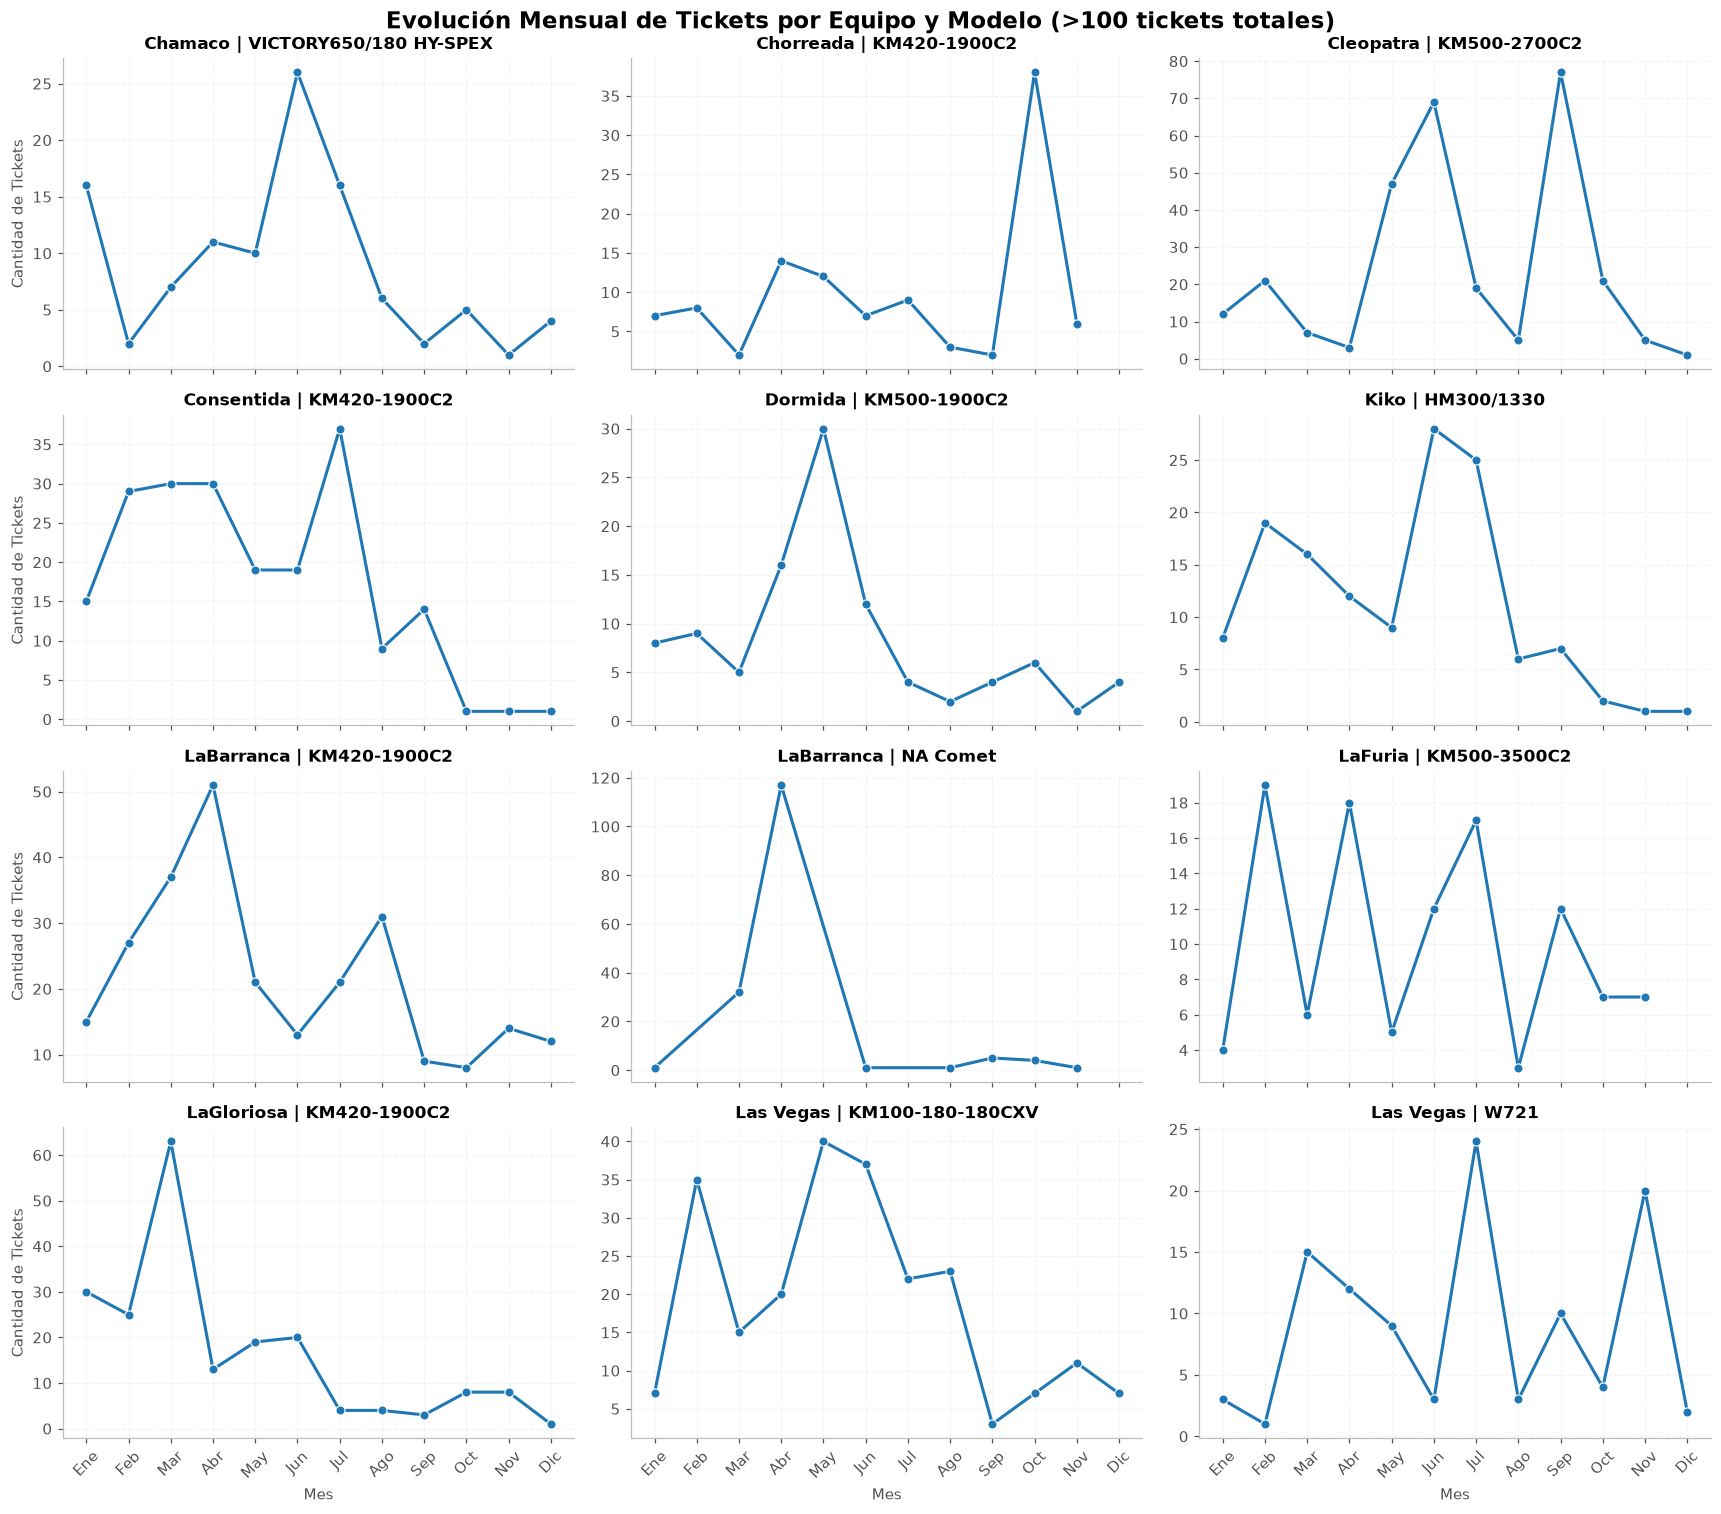

In [50]:

# Mapeo de meses (1 al 12)
meses_map = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}

# Identificar las combinaciones (Equipo - Model) que superan los 100 tickets en total
totales_por_modelo = df.groupby(['Equipo', 'Model']).size().reset_index(name='total_acumulado')
modelos_criticos = totales_por_modelo[totales_por_modelo['total_acumulado'] > 100]

# Filtrar el dataframe original manteniendo solo esas combinaciones críticas
df_filtrado = df.merge(modelos_criticos[['Equipo', 'Model']], on=['Equipo', 'Model'])

# Agrupar por Equipo, Model y Mes para obtener la frecuencia mensual
df_mensual = df_filtrado.groupby(['Equipo', 'Model', 'mes']).size().reset_index(name='num_tickets')
df_mensual['nombre_mes'] = df_mensual['mes'].map(meses_map)
df_mensual['Equipo_Model'] = df_mensual['Equipo'].astype(str) + ' | ' + df_mensual['Model'].astype(str)

# Graficar la evolución mensual por cada combinación
g = sns.FacetGrid(
    df_mensual, 
    col="Equipo_Model", 
    col_wrap=3, 
    height=3.5, 
    aspect=1.5, 
    sharey=False
)

g.map_dataframe(
    sns.lineplot, 
    x="nombre_mes", 
    y="num_tickets", 
    marker="o", 
    color="#1f77b4", 
    linewidth=2
)

# Ajustes visuales
g.set_axis_labels("Mes", "Cantidad de Tickets")
g.set_titles(col_template="{col_name}", size=11, weight='bold')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Evolución Mensual de Tickets por Equipo y Modelo (>100 tickets totales)', fontsize=15, fontweight='bold')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Utilizando únicamente las máquinas que tienen un total mayor a 100 tickets registrados, se graficó su distribución con respecto a los meses anteriores. Se puede observar cómo es que ciertas máquinas tienen comportamientos un fluctuante mientras que otras presentan patrones estacionales o picos de falla concentrados en meses específicos.